# Model performance: holdout and out-of-fold evaluation

Global comparisons combine ML and deep-learning models. Subgroup figures contain
one model experiment each. Dataset comparisons evaluate the selected model across
sibling feature-set directories. Holdout and OOF results are exported separately.


## Environment

Run the notebook from the project root or a subdirectory. Result files are discovered
recursively. All analysis outputs are written to `_comparative_analysis` under the
results directory.


In [1]:
import sys
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import pandas as pd
from IPython.display import display
from tabulate import tabulate

PROJECT_ROOT = Path("/home/paquie.d/Projet Stage M2/Clean_Build_Workpackages_Workflow")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Imports depuis ton propre projet
from utilitaries import extract_data_utils as extract
from utilitaries import postprocessing_utils as postproc
from utilitaries.figures import comparison as comparison_figures
from utilitaries.figures.performance import compute_binary_metrics
from utilitaries.static_features_utils import FR_TO_EN, GHM_CODE_TO_LABEL

PATIENT_ID_COLUMN = extract.ID_COL
all_models = []
datasets = ["Mode_IGS2", "Mode_Commonly_Used_Without_pmsi", "Mode_Commonly_Used"]

for d in datasets : 
    RESULTS_ROOT = PROJECT_ROOT / "outputs/no_duplicates_prio_first/isDeceased_lt_28d/target_col/24h_debut_rea_no-fill" / d
    DATAFRAME_PATH = Path("/data2/paquie.d/Datasets/output/clean_full_static.parquet")

    OUTPUT_DIR = RESULTS_ROOT / "_comparative_analysis"
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    # --- 4. Vérifications ---
    print(f"Dossier de sortie : {OUTPUT_DIR}")

/home/paquie.d/Projet Stage M2/.venv312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dossier de sortie : /home/paquie.d/Projet Stage M2/Clean_Build_Workpackages_Workflow/outputs/no_duplicates_prio_first/isDeceased_lt_28d/target_col/24h_debut_rea_no-fill/Mode_IGS2/_comparative_analysis
Dossier de sortie : /home/paquie.d/Projet Stage M2/Clean_Build_Workpackages_Workflow/outputs/no_duplicates_prio_first/isDeceased_lt_28d/target_col/24h_debut_rea_no-fill/Mode_Commonly_Used_Without_pmsi/_comparative_analysis
Dossier de sortie : /home/paquie.d/Projet Stage M2/Clean_Build_Workpackages_Workflow/outputs/no_duplicates_prio_first/isDeceased_lt_28d/target_col/24h_debut_rea_no-fill/Mode_Commonly_Used/_comparative_analysis


## Global comparison: all model families

One ROC/PR/calibration figure overlays all experiments.


8 résultats chargés avec succès.

=== OOF PERFORMANCE COMPARISON TABLE ===
╒═════════════════════╤═══════════════╤═══════════════╤═══════════════╤═══════════════╤═══════════════╤════════════════╤═══════════════╤═══════════════╤═══════════════╕
│                     │ AUROC         │ AUPRC         │ F1-Score      │ MCC           │ Brier         │ Intercept      │ Slope         │ ICI           │ E90           │
╞═════════════════════╪═══════════════╪═══════════════╪═══════════════╪═══════════════╪═══════════════╪════════════════╪═══════════════╪═══════════════╪═══════════════╡
│ IGS2                │ 0.759 ± 0.016 │ 0.430 ± 0.033 │ 0.476 ± 0.020 │ 0.325 ± 0.029 │ 0.212 ± 0.009 │ -1.406 ± 0.022 │ 0.544 ± 0.040 │ 0.218 ± 0.008 │ 0.432 ± 0.032 │
├─────────────────────┼───────────────┼───────────────┼───────────────┼───────────────┼───────────────┼────────────────┼───────────────┼───────────────┼───────────────┤
│ L1-LR               │ 0.791 ± 0.011 │ 0.493 ± 0.019 │ 0.496 ± 0.022 │ 0.362 ± 

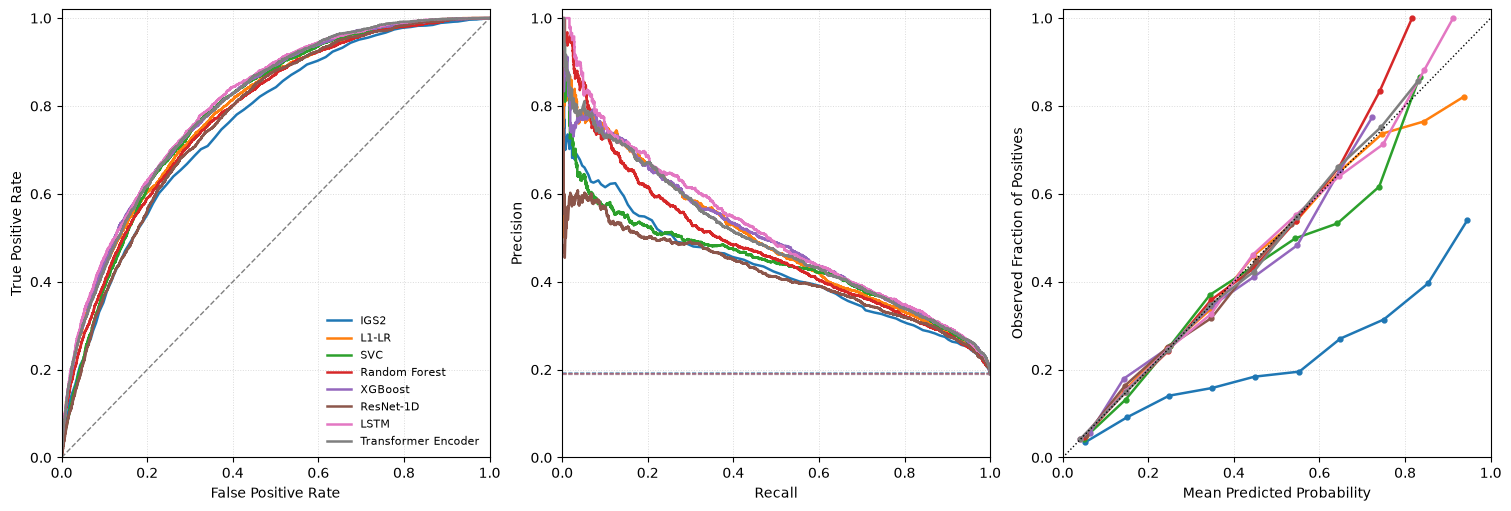


=== Holdout PERFORMANCE COMPARISON TABLE ===
╒═════════════════════╤══════════════════════╤══════════════════════╤══════════════════════╤══════════════════════╤══════════════════════╤═════════════════════════╤══════════════════════╤══════════════════════╤══════════════════════╕
│                     │ AUROC                │ AUPRC                │ F1-Score             │ MCC                  │ Brier                │ Intercept               │ Slope                │ ICI                  │ E90                  │
╞═════════════════════╪══════════════════════╪══════════════════════╪══════════════════════╪══════════════════════╪══════════════════════╪═════════════════════════╪══════════════════════╪══════════════════════╪══════════════════════╡
│ IGS2                │ 0.741 [0.717, 0.763] │ 0.396 [0.355, 0.440] │ 0.458 [0.421, 0.491] │ 0.302 [0.258, 0.341] │ 0.220 [0.210, 0.231] │ -1.401 [-1.512, -1.298] │ 0.495 [0.436, 0.558] │ 0.224 [0.209, 0.241] │ 0.437 [0.405, 0.496] │
├─────────────────

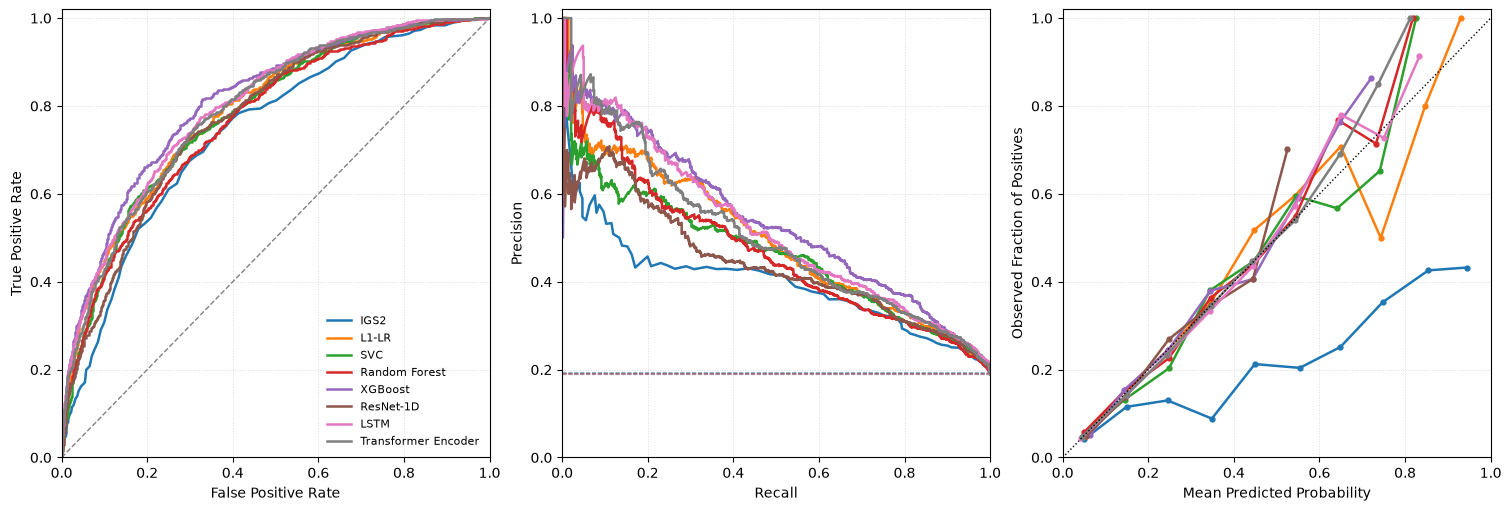

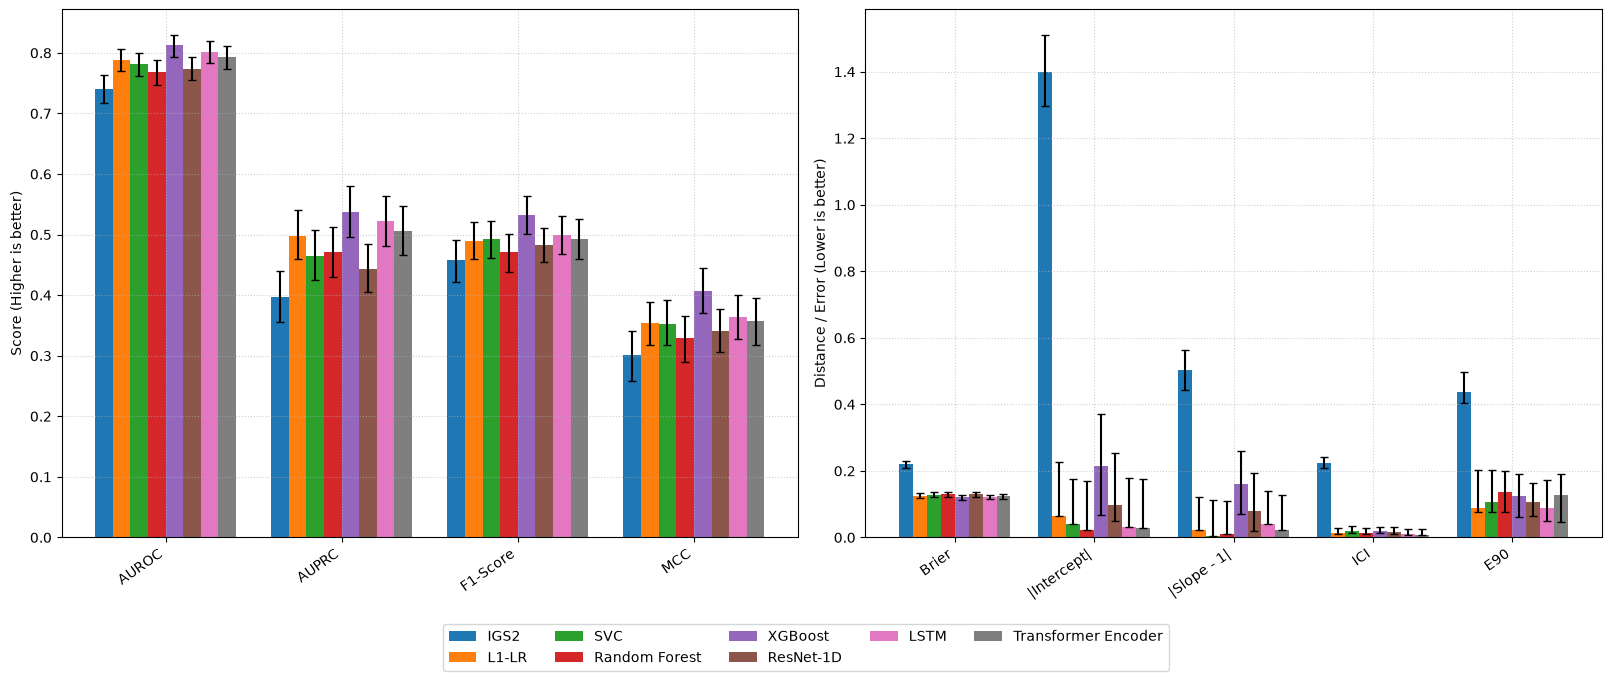

16 résultats chargés avec succès.

=== OOF PERFORMANCE COMPARISON TABLE ===
╒═════════════════════╤═══════════════╤═══════════════╤═══════════════╤═══════════════╤═══════════════╤════════════════╤═══════════════╤═══════════════╤═══════════════╕
│                     │ AUROC         │ AUPRC         │ F1-Score      │ MCC           │ Brier         │ Intercept      │ Slope         │ ICI           │ E90           │
╞═════════════════════╪═══════════════╪═══════════════╪═══════════════╪═══════════════╪═══════════════╪════════════════╪═══════════════╪═══════════════╪═══════════════╡
│ IGS2                │ 0.759 ± 0.016 │ 0.430 ± 0.033 │ 0.476 ± 0.020 │ 0.325 ± 0.029 │ 0.212 ± 0.009 │ -1.406 ± 0.022 │ 0.544 ± 0.040 │ 0.218 ± 0.008 │ 0.432 ± 0.032 │
├─────────────────────┼───────────────┼───────────────┼───────────────┼───────────────┼───────────────┼────────────────┼───────────────┼───────────────┼───────────────┤
│ L1-LR               │ 0.816 ± 0.010 │ 0.534 ± 0.016 │ 0.530 ± 0.010 │ 0.408 ±

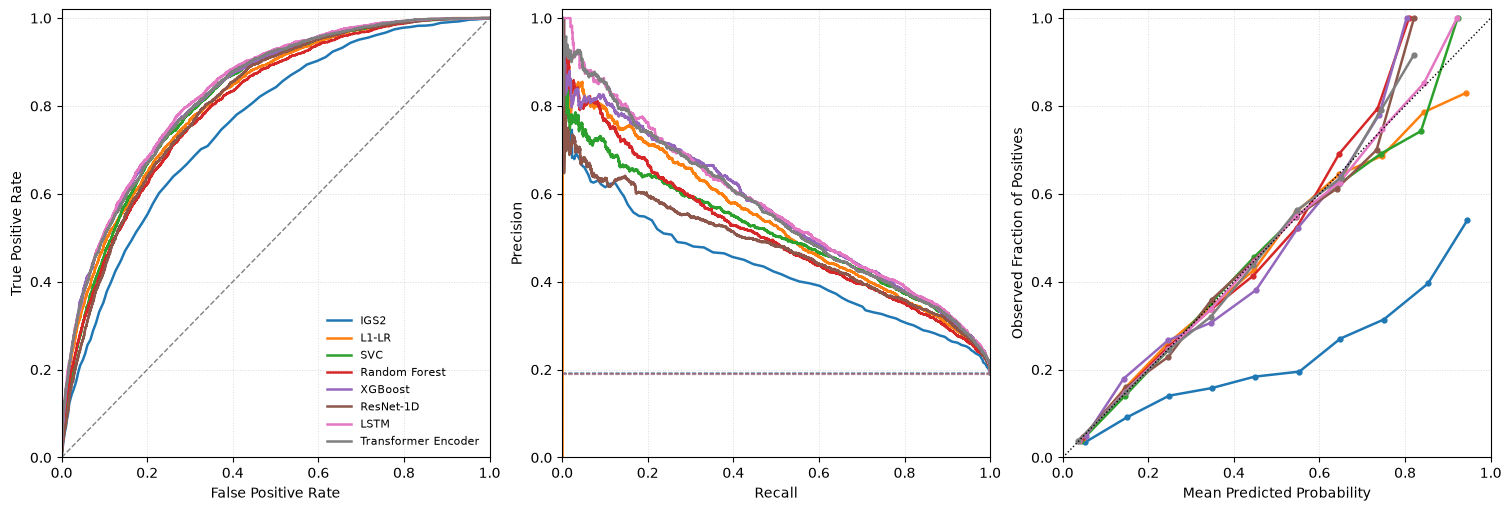


=== Holdout PERFORMANCE COMPARISON TABLE ===
╒═════════════════════╤══════════════════════╤══════════════════════╤══════════════════════╤══════════════════════╤══════════════════════╤═════════════════════════╤══════════════════════╤══════════════════════╤══════════════════════╕
│                     │ AUROC                │ AUPRC                │ F1-Score             │ MCC                  │ Brier                │ Intercept               │ Slope                │ ICI                  │ E90                  │
╞═════════════════════╪══════════════════════╪══════════════════════╪══════════════════════╪══════════════════════╪══════════════════════╪═════════════════════════╪══════════════════════╪══════════════════════╪══════════════════════╡
│ IGS2                │ 0.741 [0.717, 0.763] │ 0.396 [0.355, 0.440] │ 0.458 [0.421, 0.491] │ 0.302 [0.258, 0.341] │ 0.220 [0.210, 0.231] │ -1.401 [-1.512, -1.298] │ 0.495 [0.436, 0.558] │ 0.224 [0.209, 0.241] │ 0.437 [0.405, 0.496] │
├─────────────────

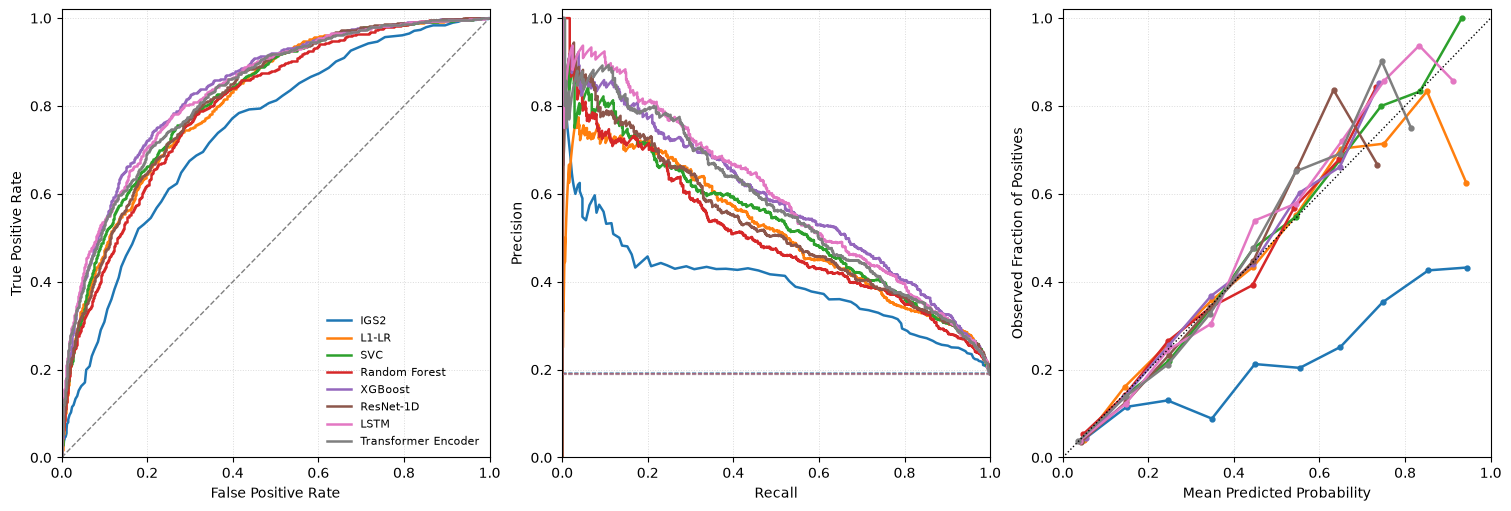

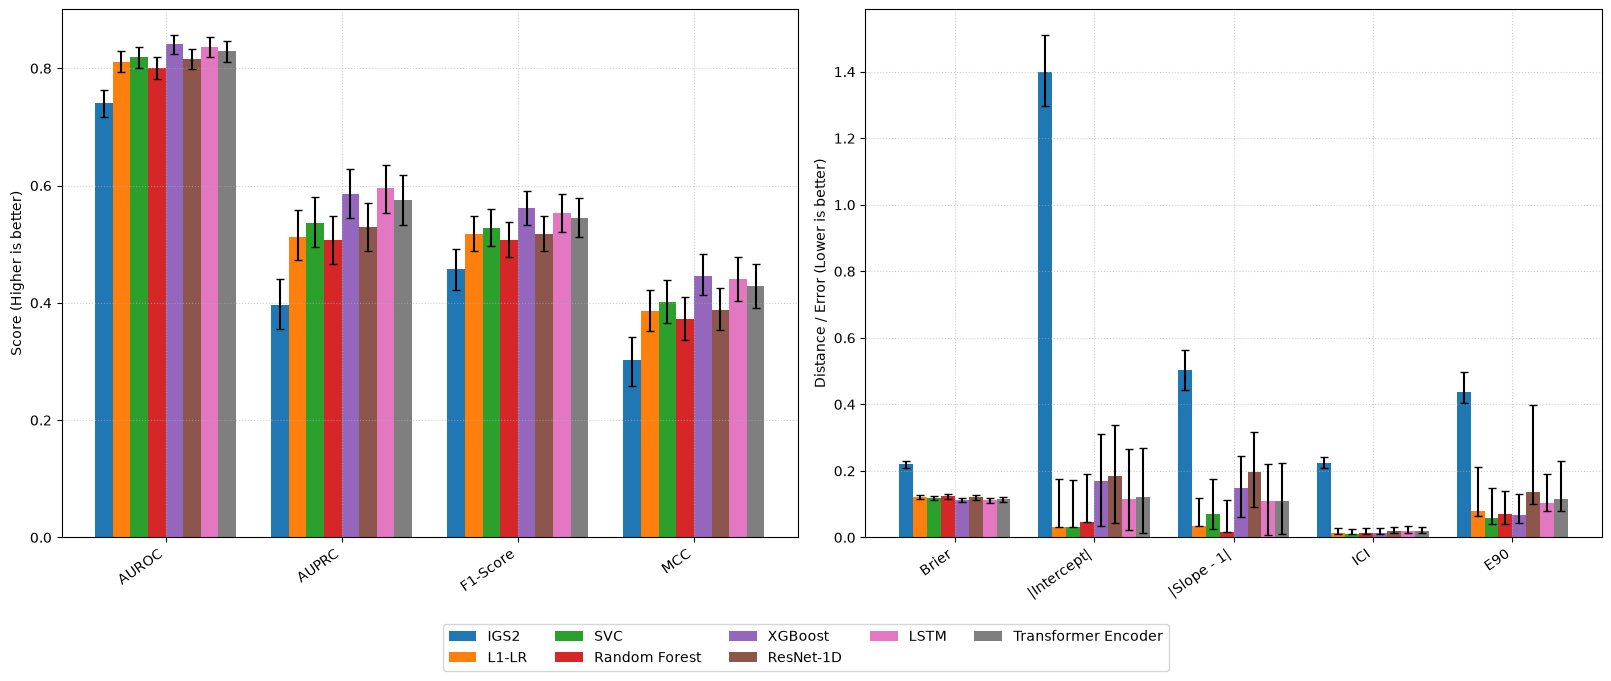

24 résultats chargés avec succès.

=== OOF PERFORMANCE COMPARISON TABLE ===
╒═════════════════════╤═══════════════╤═══════════════╤═══════════════╤═══════════════╤═══════════════╤════════════════╤═══════════════╤═══════════════╤═══════════════╕
│                     │ AUROC         │ AUPRC         │ F1-Score      │ MCC           │ Brier         │ Intercept      │ Slope         │ ICI           │ E90           │
╞═════════════════════╪═══════════════╪═══════════════╪═══════════════╪═══════════════╪═══════════════╪════════════════╪═══════════════╪═══════════════╪═══════════════╡
│ IGS2                │ 0.759 ± 0.016 │ 0.430 ± 0.033 │ 0.476 ± 0.020 │ 0.325 ± 0.029 │ 0.212 ± 0.009 │ -1.406 ± 0.022 │ 0.544 ± 0.040 │ 0.218 ± 0.008 │ 0.432 ± 0.032 │
├─────────────────────┼───────────────┼───────────────┼───────────────┼───────────────┼───────────────┼────────────────┼───────────────┼───────────────┼───────────────┤
│ L1-LR               │ 0.826 ± 0.007 │ 0.557 ± 0.012 │ 0.539 ± 0.010 │ 0.418 ±

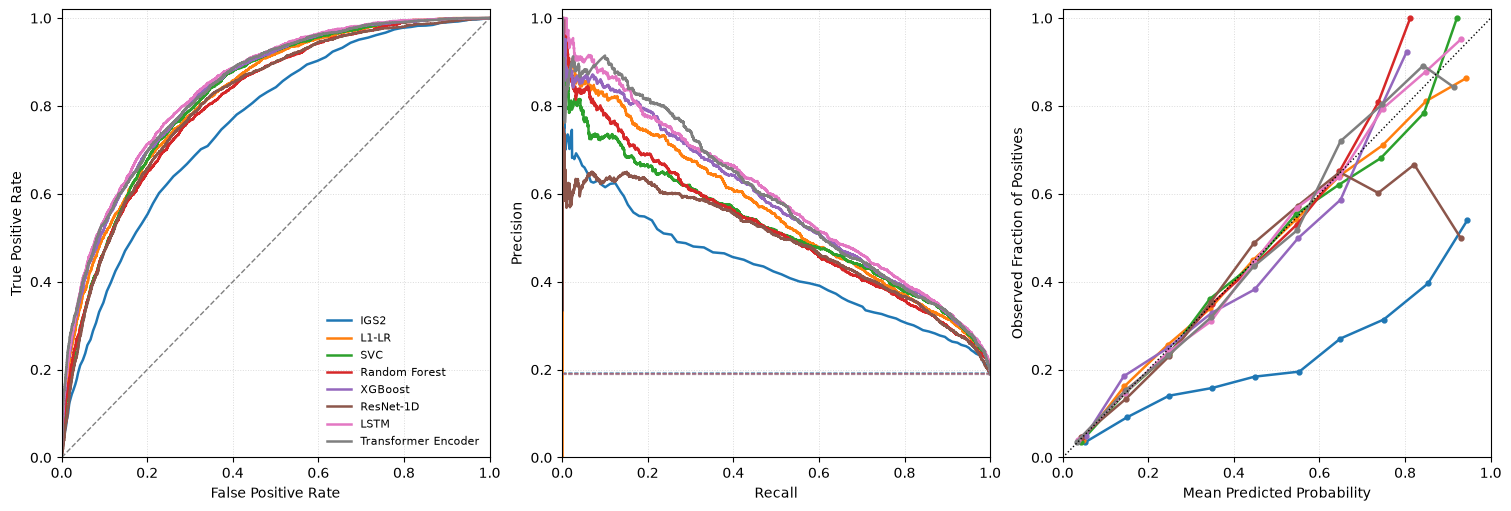


=== Holdout PERFORMANCE COMPARISON TABLE ===
╒═════════════════════╤══════════════════════╤══════════════════════╤══════════════════════╤══════════════════════╤══════════════════════╤═════════════════════════╤══════════════════════╤══════════════════════╤══════════════════════╕
│                     │ AUROC                │ AUPRC                │ F1-Score             │ MCC                  │ Brier                │ Intercept               │ Slope                │ ICI                  │ E90                  │
╞═════════════════════╪══════════════════════╪══════════════════════╪══════════════════════╪══════════════════════╪══════════════════════╪═════════════════════════╪══════════════════════╪══════════════════════╪══════════════════════╡
│ IGS2                │ 0.741 [0.717, 0.763] │ 0.396 [0.355, 0.440] │ 0.458 [0.421, 0.491] │ 0.302 [0.258, 0.341] │ 0.220 [0.210, 0.231] │ -1.401 [-1.512, -1.298] │ 0.495 [0.436, 0.558] │ 0.224 [0.209, 0.241] │ 0.437 [0.405, 0.496] │
├─────────────────

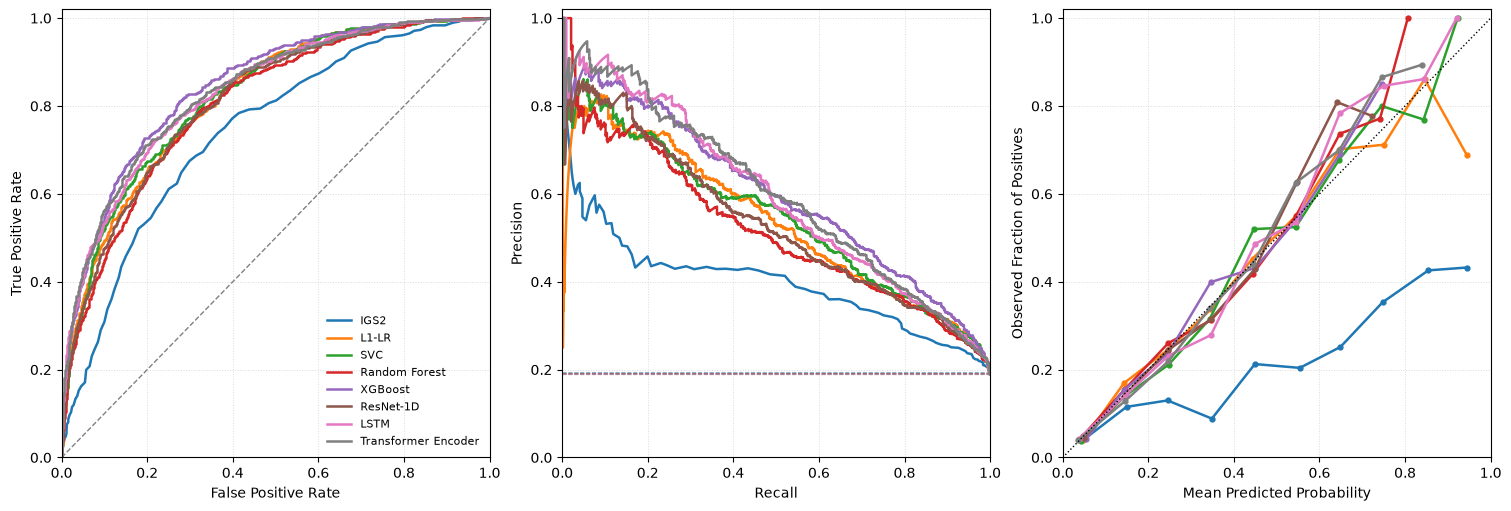

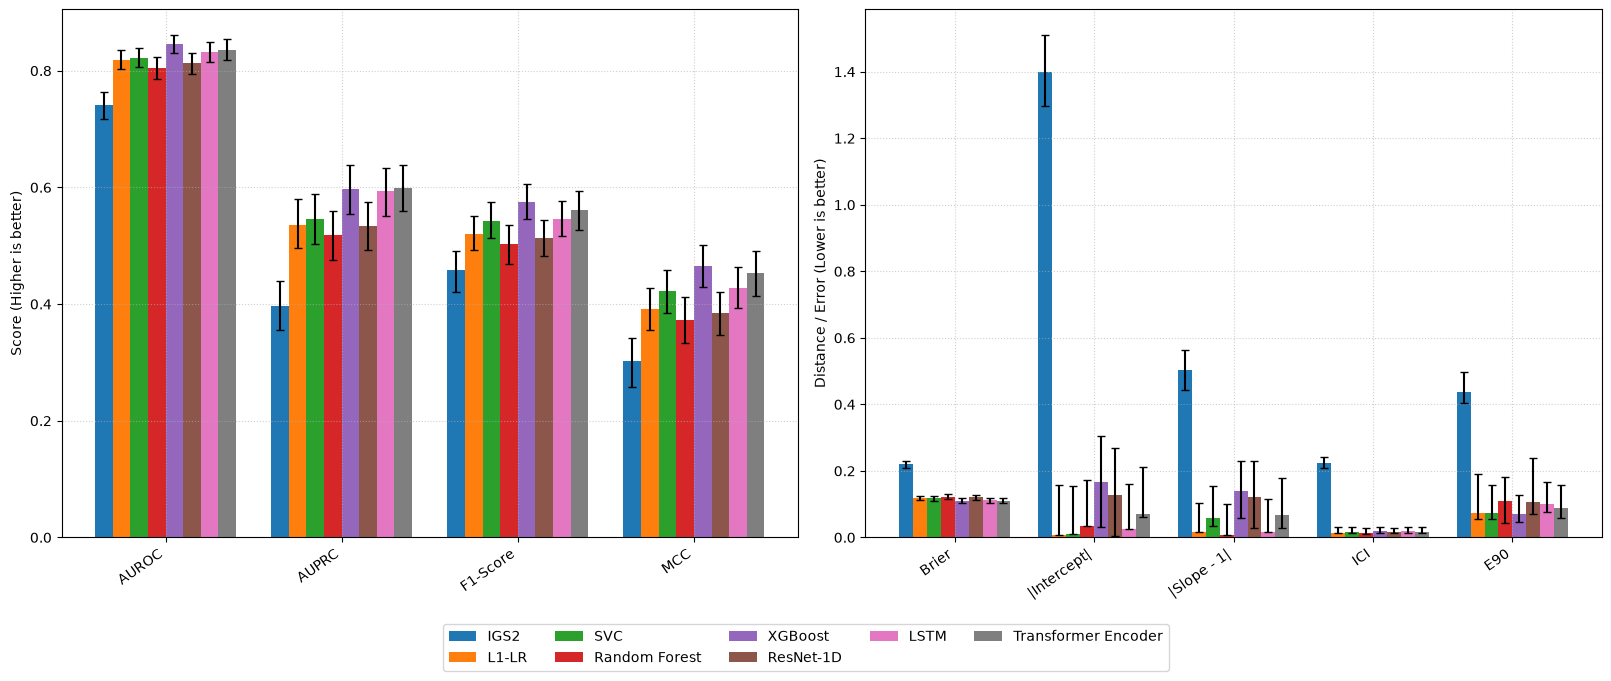

In [3]:
for d in datasets : 
    RESULTS_ROOT = PROJECT_ROOT / "outputs/no_duplicates_prio_first/isDeceased_lt_28d/target_col/24h_debut_rea_no-fill" / d
    DATAFRAME_PATH = Path("/data2/paquie.d/Datasets/output/clean_full_static.parquet")

    OUTPUT_DIR = RESULTS_ROOT / "_comparative_analysis"
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    # 1. Trouver tous les fichiers all_res.joblib (en ignorant le dossier de sortie)
    files = sorted(p for p in RESULTS_ROOT.rglob("all_res.joblib") if OUTPUT_DIR not in p.parents)

    # 2. Charger directement les données
    for path in files:
        data = joblib.load(path)
        
        all_models.append({
            "path": path,
            "model": path.parent.parent.name,
            "run": path.parent.name,
            "y": data["y_true_holdout"],
            "p": data["probas_holdout"],
            "ids": data["holdout_patient_ids"],
            "threshold": data["fixed_threshold_from_oof"]
        })

    print(f"{len(all_models)} résultats chargés avec succès.")

    # 1. Charger les résultats directement
    configurations = []
    files = sorted(
        p for p in RESULTS_ROOT.rglob("all_res.joblib") if OUTPUT_DIR not in p.parents
    )

    for path in files:
        data = joblib.load(path)
        model_name = path.parent.parent.name
        configurations.append((model_name, data))

    df_results_OOF = comparison_figures.generate_comparative_report(
        configurations=configurations,
        evaluation_mode="oof",
        save_dir=OUTPUT_DIR,
        output_format="pdf",
        show=True,
        save_individual_plots = True
    )

    # 2. Générer le rapport comparatif complet
    df_results_holdout = comparison_figures.generate_comparative_report(
        configurations=configurations,
        evaluation_mode="holdout",
        save_dir=OUTPUT_DIR,
        output_format="pdf",
        show=True,
        save_individual_plots = True
    )

## Patient metadata and subgroup labels

Patient IDs use `extract_data_utils.ID_COL`. Admission categories remain distinct.
Age 70 belongs to the 55–70 group. GHM labels and gender translations come from
`static_features_utils`. Sepsis overrides the disease label only when a `sepsis`
column is available. Missing subgroup columns are reported and omitted.

Identical subgroup records are collapsed by patient ID. Conflicting subgroup
assignments raise an error. Missing patient metadata forms an explicit subgroup.



=== Holdout PERFORMANCE COMPARISON TABLE ===
╒═══════╤══════════════════════╤══════════════════════╤══════════════════════╤══════════════════════╤══════════════════════╤═══════════════════════╤══════════════════════╤══════════════════════╤══════════════════════╕
│       │ AUROC                │ AUPRC                │ F1-Score             │ MCC                  │ Brier                │ Intercept             │ Slope                │ ICI                  │ E90                  │
╞═══════╪══════════════════════╪══════════════════════╪══════════════════════╪══════════════════════╪══════════════════════╪═══════════════════════╪══════════════════════╪══════════════════════╪══════════════════════╡
│ 40-55 │ 0.853 [0.804, 0.897] │ 0.569 [0.453, 0.676] │ 0.578 [0.485, 0.660] │ 0.504 [0.402, 0.597] │ 0.085 [0.071, 0.101] │ 0.010 [-0.366, 0.406] │ 1.123 [0.919, 1.364] │ 0.031 [0.021, 0.058] │ 0.174 [0.104, 0.320] │
├───────┼──────────────────────┼──────────────────────┼──────────────────────┼────

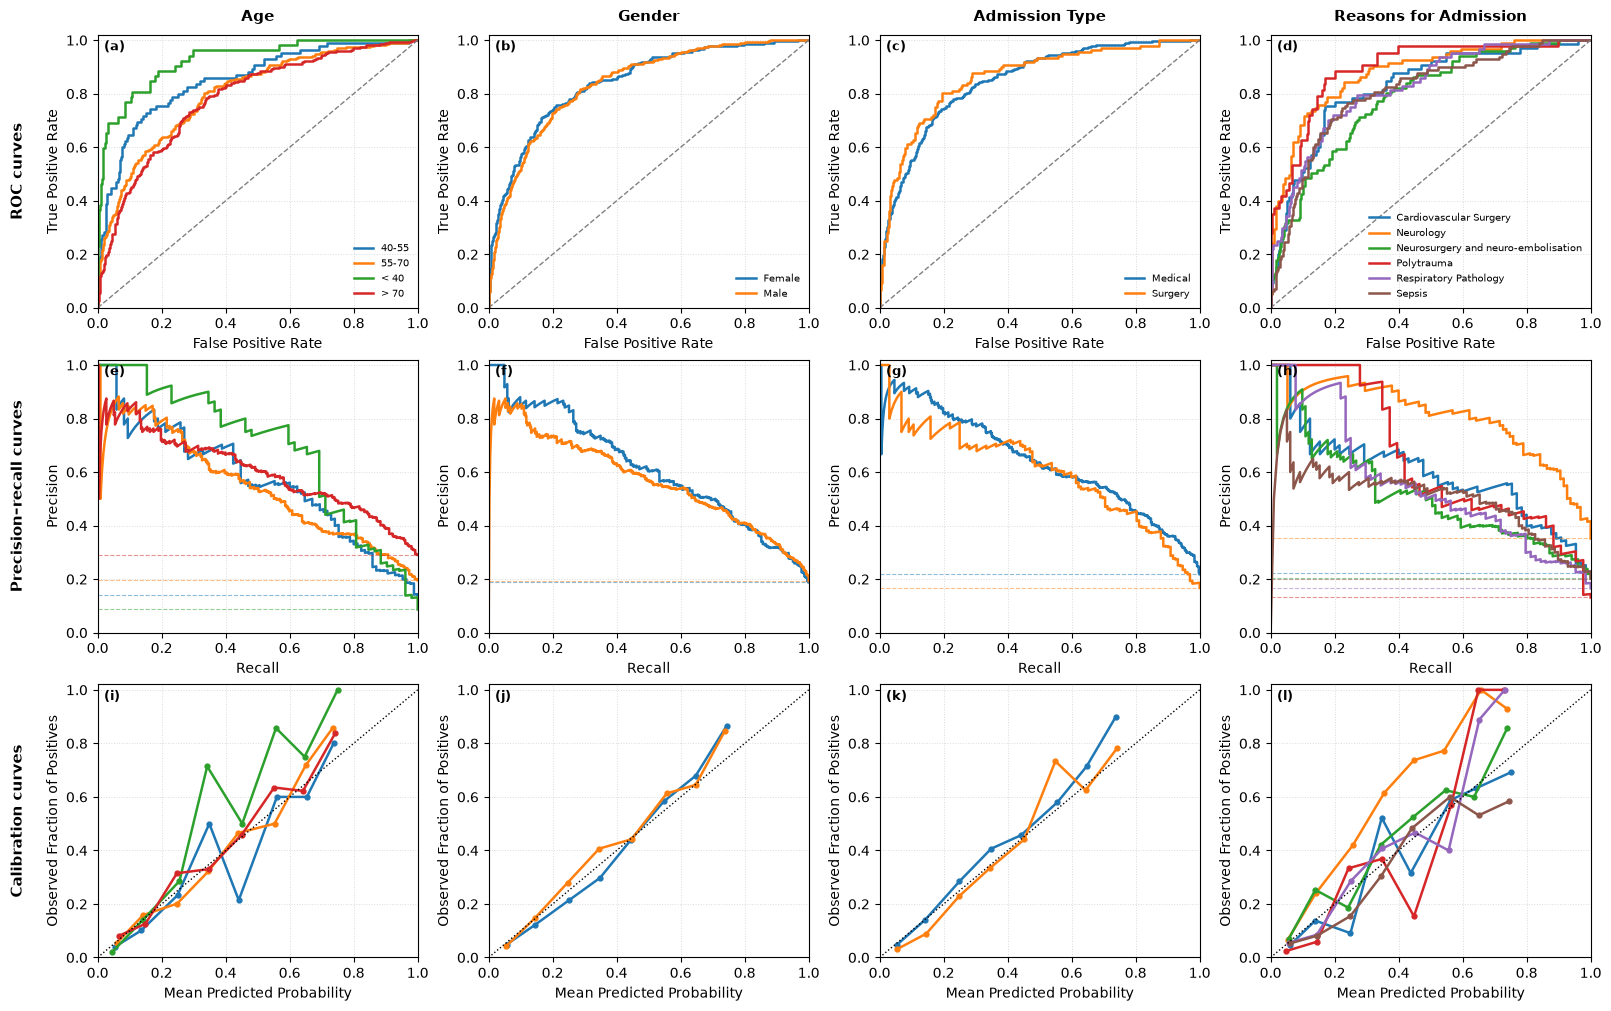

In [5]:
import numpy as np
import polars as pl

tested_model = "XGBoost_TSFEL"
pretty_label = {
    "LstmTimeModified": "LSTM",
    "XGBoost_TSFEL": "XGBoost",
    "XGBoost TSFEL": "XGBoost",
}

codes_cim = [
    "R57.2", "R65.1", "A02.1", "A22.7", "A26.7", "A32.7", "A42.7", "B37.7",
    "O85", "A40.0", "A40.1", "A40.2", "A40.3", "A40.8", "A40.9", "A41.0",
    "A41.1", "A41.2", "A41.3", "A41.4", "A41.5", "A41.8", "A41.9", "P36.00",
    "P36.10", "P36.20", "P36.30", "P36.40", "P36.50", "P36.80", "P36.90",
]

ADMISSION_MAP = {
    "Scheduled Surgery": "Surgery",
    "Unscheduled Surgery": "Surgery",
}

# Tes 5 pathologies cibles
TOP_REASONS = [
    "Neurosurgery and neuro-embolisation",
    "Respiratory Pathology",
    "Polytrauma",
    "Cardiovascular Surgery",
    "Neurology",
]

ORDERED_SUBGROUPS = [
    {
        "col": "Age",
        "name": "Age",
        "order": ["< 40", "40-55", "55-70", "> 70"],
    },
    {
        "col": "Gender",
        "name": "Gender",
        "order": ["Male", "Female"],
    },
    {
        "col": "Admission Type",
        "name": "Admission Type",
        "order": ["Medical", "Surgery"],
    },
    {
        "col": "Reasons for Admission",
        "name": "Reasons for Admission",
        "order": [
            "Cardiovascular Surgery",
            "Neurology",
            "Neurosurgery and neuro-embolisation",
            "Polytrauma",
            "Respiratory Pathology",
            "Sepsis",
        ],
    },
]

# 1. Lecture de la table patients
df = (
    pl.read_parquet(DATAFRAME_PATH)
    .unique(subset=[PATIENT_ID_COLUMN])
    .with_columns(pl.col(PATIENT_ID_COLUMN).cast(pl.String))
)

# 2. Détection du Sepsis
is_sepsis = (
    pl.col("icu_DA").list.eval(pl.element().is_in(codes_cim)).list.any().fill_null(False)
    | pl.col("icu_DP_code").is_in(codes_cim).fill_null(False)
)

# 3. Libellé GHM
ghm_prefix = (
    pl.col("icu_ghm")
    .list.first()
    .cast(pl.String)
    .str.slice(0, 3)
)

raw_reason = (
    pl.when(is_sepsis)
    .then(pl.lit("Sepsis"))
    .otherwise(
        ghm_prefix.replace_strict(GHM_CODE_TO_LABEL, default=pl.lit(None))
    )
)

# 4. Table des sous-groupes (valeurs non retenues -> null)
subgroups_pl = df.select(
    pl.col(PATIENT_ID_COLUMN),

    # Age
    pl.when(pl.col("age") < 40).then(pl.lit("< 40"))
      .when(pl.col("age") < 55).then(pl.lit("40-55"))
      .when(pl.col("age") <= 70).then(pl.lit("55-70"))
      .otherwise(pl.lit("> 70"))
      .alias("Age"),

    # Gender
    pl.col("gender").replace_strict(FR_TO_EN, default=pl.lit(None)).alias("Gender"),

    # Admission Type : fusion chirurgie
    pl.col("admission_type")
      .replace_strict(ADMISSION_MAP, default=pl.col("admission_type"))
      .alias("Admission Type"),

    # Reasons for Admission : uniquement le Top + Sepsis, sinon None
    pl.when(raw_reason == "Sepsis")
      .then(pl.lit("Sepsis"))
      .when(raw_reason.is_in(TOP_REASONS))
      .then(raw_reason)
      .otherwise(pl.lit(None))
      .alias("Reasons for Admission"),
)

# 5. Boucle sur les modèles
for m in all_models:
    if m["model"] == tested_model:
        clean_ids = np.asarray(m["ids"], dtype=np.int64).astype(str)
        m_ids_df = pl.DataFrame({PATIENT_ID_COLUMN: clean_ids})

        aligned = m_ids_df.join(subgroups_pl, on=PATIENT_ID_COLUMN, how="left")

        subgroup_configs = []
        for cfg in ORDERED_SUBGROUPS:
            col_name = cfg["col"]
            if col_name not in aligned.columns:
                continue

            # Remplacement des None par une étiquette temporaire
            # ou filtrage selon ce que supporte comparison_figures
            raw_labels = aligned[col_name].to_numpy()
            
            # Si comparison_figures trace toutes les clés uniques trouvées :
            # Remplacer les None par des chaînes évite le crash du sort NumPy :
            safe_labels = np.array(
                [str(x) if x is not None else "IGNORE" for x in raw_labels],
                dtype=object
            )

            subgroup_configs.append({
                "name": cfg["name"],
                "labels": safe_labels,
                "order": cfg["order"],
            })
        output_path = OUTPUT_DIR / f"subgroup_{m['model']}.pdf"

        comparison_figures.generate_subgroup_grid_from_configs(
            probas=m["p"],
            y_true=m["y"],
            subgroup_configs=subgroup_configs,
            model_title=pretty_label.get(m["model"], m["model"].replace("_", " ")),
            save_path=output_path,
            output_format="pdf",
            show=True,
        )

## Dataset comparison for the selected model

`DATASET_COMPARISON_MODEL` selects one model. The search covers the sibling feature-set
directories under `RESULTS_ROOT.parent`, e.g. the different `Mode_*` directories
within the same outcome and time-window configuration. No additional path is required.

Dataset labels include the feature-set directory and run identifier. Runs are not
averaged together. This comparison retains each dataset's own complete holdout;
sample sizes and prevalence are exported. Differences can reflect population as
well as feature-set differences when the patients are not identical.


3 configurations trouvées pour LstmTimeModified.

=== Holdout PERFORMANCE COMPARISON TABLE ===
╒══════════════════════════╤══════════════════════╤══════════════════════╤══════════════════════╤══════════════════════╤══════════════════════╤═══════════════════════╤══════════════════════╤══════════════════════╤══════════════════════╕
│                          │ AUROC                │ AUPRC                │ F1-Score             │ MCC                  │ Brier                │ Intercept             │ Slope                │ ICI                  │ E90                  │
╞══════════════════════════╪══════════════════════╪══════════════════════╪══════════════════════╪══════════════════════╪══════════════════════╪═══════════════════════╪══════════════════════╪══════════════════════╪══════════════════════╡
│ IGS2 Predictor Set       │ 0.801 [0.783, 0.819] │ 0.522 [0.482, 0.563] │ 0.499 [0.467, 0.530] │ 0.364 [0.327, 0.401] │ 0.121 [0.114, 0.129] │ 0.032 [-0.108, 0.178] │ 1.041 [0.947, 1.141] │ 0.0

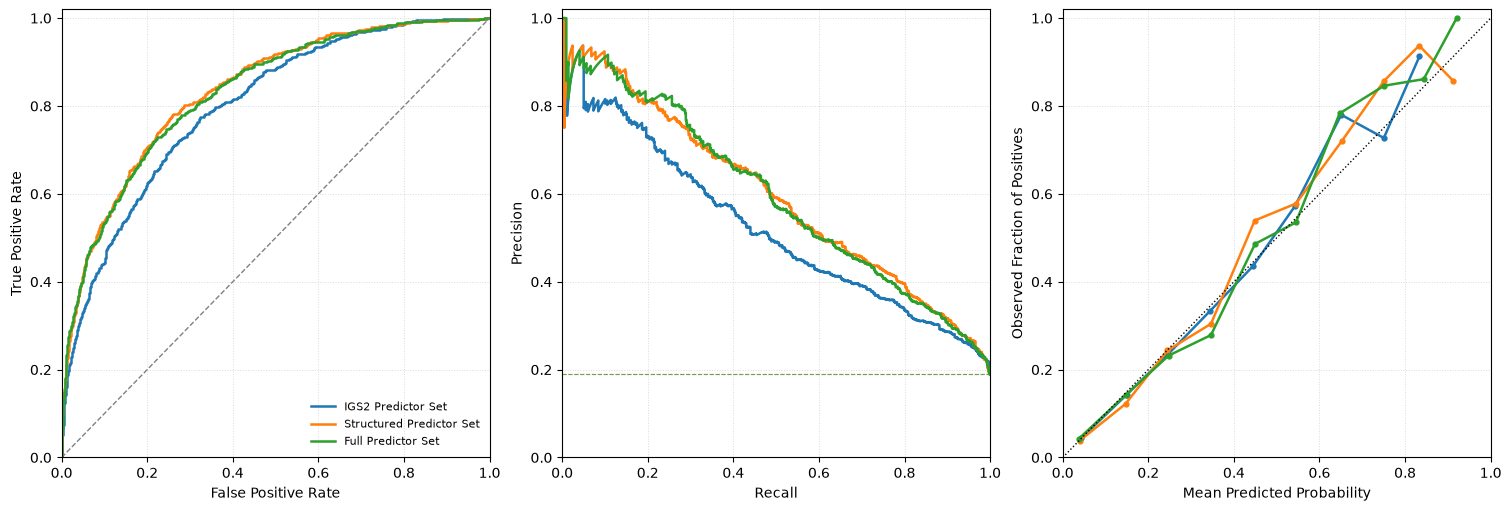

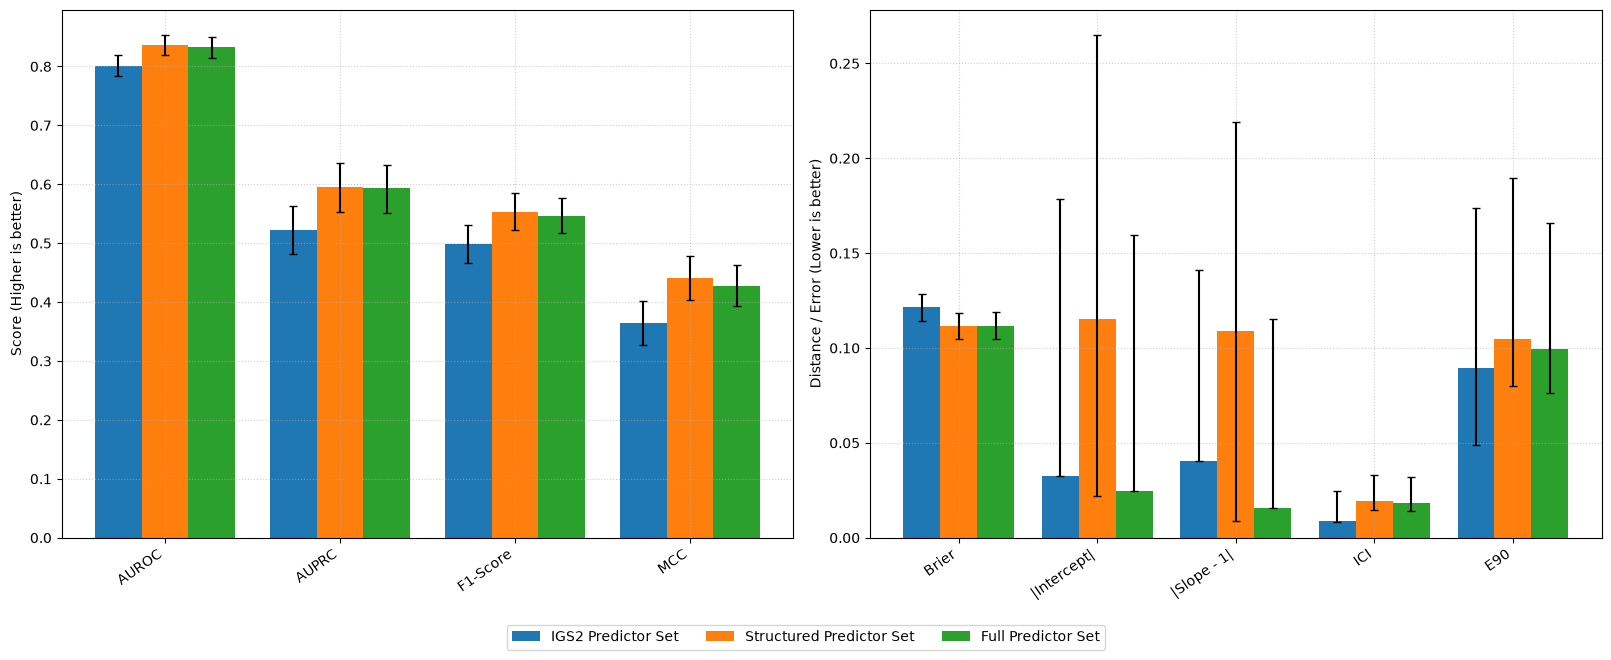

In [4]:
DATASET_COMPARISON_MODEL = "LstmTimeModified"
DATASET_RESULTS_ROOT = RESULTS_ROOT.parent
dataset_folder = Path(f"outputs/no_duplicates_prio_first/isDeceased_lt_28d/target_col/24h_debut_rea_no-fill/dataset_comparison/{DATASET_COMPARISON_MODEL}")
dataset_folder.mkdir(parents=True, exist_ok=True)

pretty_mode = {
    "Mode_IGS2" : "IGS2 Predictor Set",
    "Mode_Commonly_Used_Without_pmsi" : "Structured Predictor Set",
    "Mode_Commonly_Used" : "Full Predictor Set"
}
# 1. Sélectionner les fichiers du modèle cible (insensible à la casse / underscores)
target = DATASET_COMPARISON_MODEL.replace("_", " ").lower().strip()
dataset_configurations = []

for path in sorted(DATASET_RESULTS_ROOT.rglob("all_res.joblib")):
    if "_comparative_analysis" in path.parts:
        continue

    model_dir_name = path.parent.parent.name.replace("_", " ").lower().strip()
    if model_dir_name == target:
        # Libellé lisible : NomDuMode · run
        mode_name = path.parent.parent.parent.name
        run_name = path.parent.name
        label = pretty_mode.get(f"{mode_name}")

        data = joblib.load(path)
        dataset_configurations.append((label, data))

print(
    f"{len(dataset_configurations)} configurations trouvées pour {DATASET_COMPARISON_MODEL}."
)

# 2. Générer les courbes comparatives (ROC, PRC, Calibration) et le tableau
if dataset_configurations:
    table = comparison_figures.generate_comparative_report(
        configurations=dataset_configurations,
        evaluation_mode="holdout",
        save_dir=dataset_folder,
        output_format="pdf",
        show=True,
        order=[
            "IGS2 Predictor Set",
            "Structured Predictor Set",
            "Full Predictor Set",
        ],
    )

## Paired Bootstrap Analysis: Model Comparison & Forest Plots

This section evaluates pairwise performance differences using paired bootstrap distributions
computed on the test holdout set. For each feature-set directory (`Mode_*`), results are 
loaded from individual model runs while strictly excluding the baseline `igs2` scoring model.

Pairwise differences are assessed across evaluation metrics to generate forest plots: first for
the reference triplet (`L1-LR`, `XGBoost`, and `LSTM`), followed by an exhaustive sweep of all
possible pairwise model combinations ($n$-choose-2). Because resamples are paired across identical
patient holdouts within each feature set, confidence intervals directly reflect relative model
discrepancies rather than sample-level variance.


[Mode_IGS2] 7 models loaded (excluding IGS2): ['InceptionTimeModified', 'Logistic_Regression_Lasso_TSFEL', 'LstmTimeModified', 'RandomForest_TSFEL', 'SVC_TSFEL', 'VanillaTransformerModified', 'XGBoost_TSFEL']


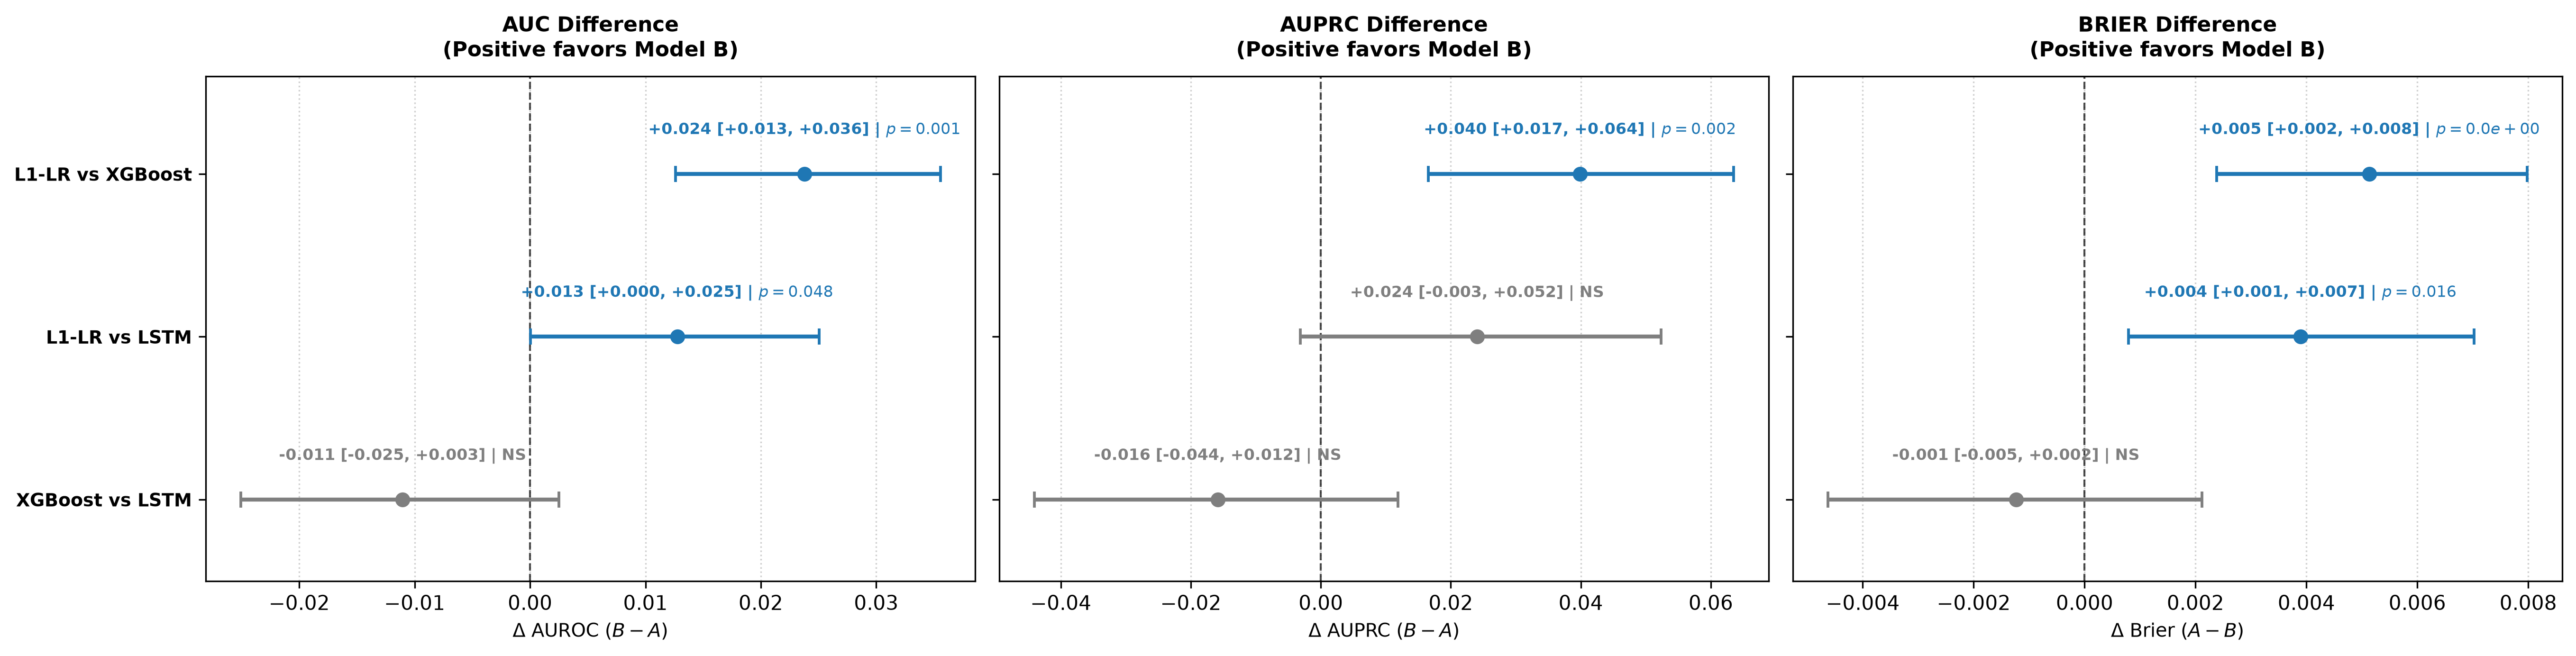

[Done] Processed 3 model comparison pairs.
[Saved] Figure: triplet_paired_bootstrap_auc_auprc_brier.pdf | Data: triplet_paired_bootstrap_auc_auprc_brier_data.csv


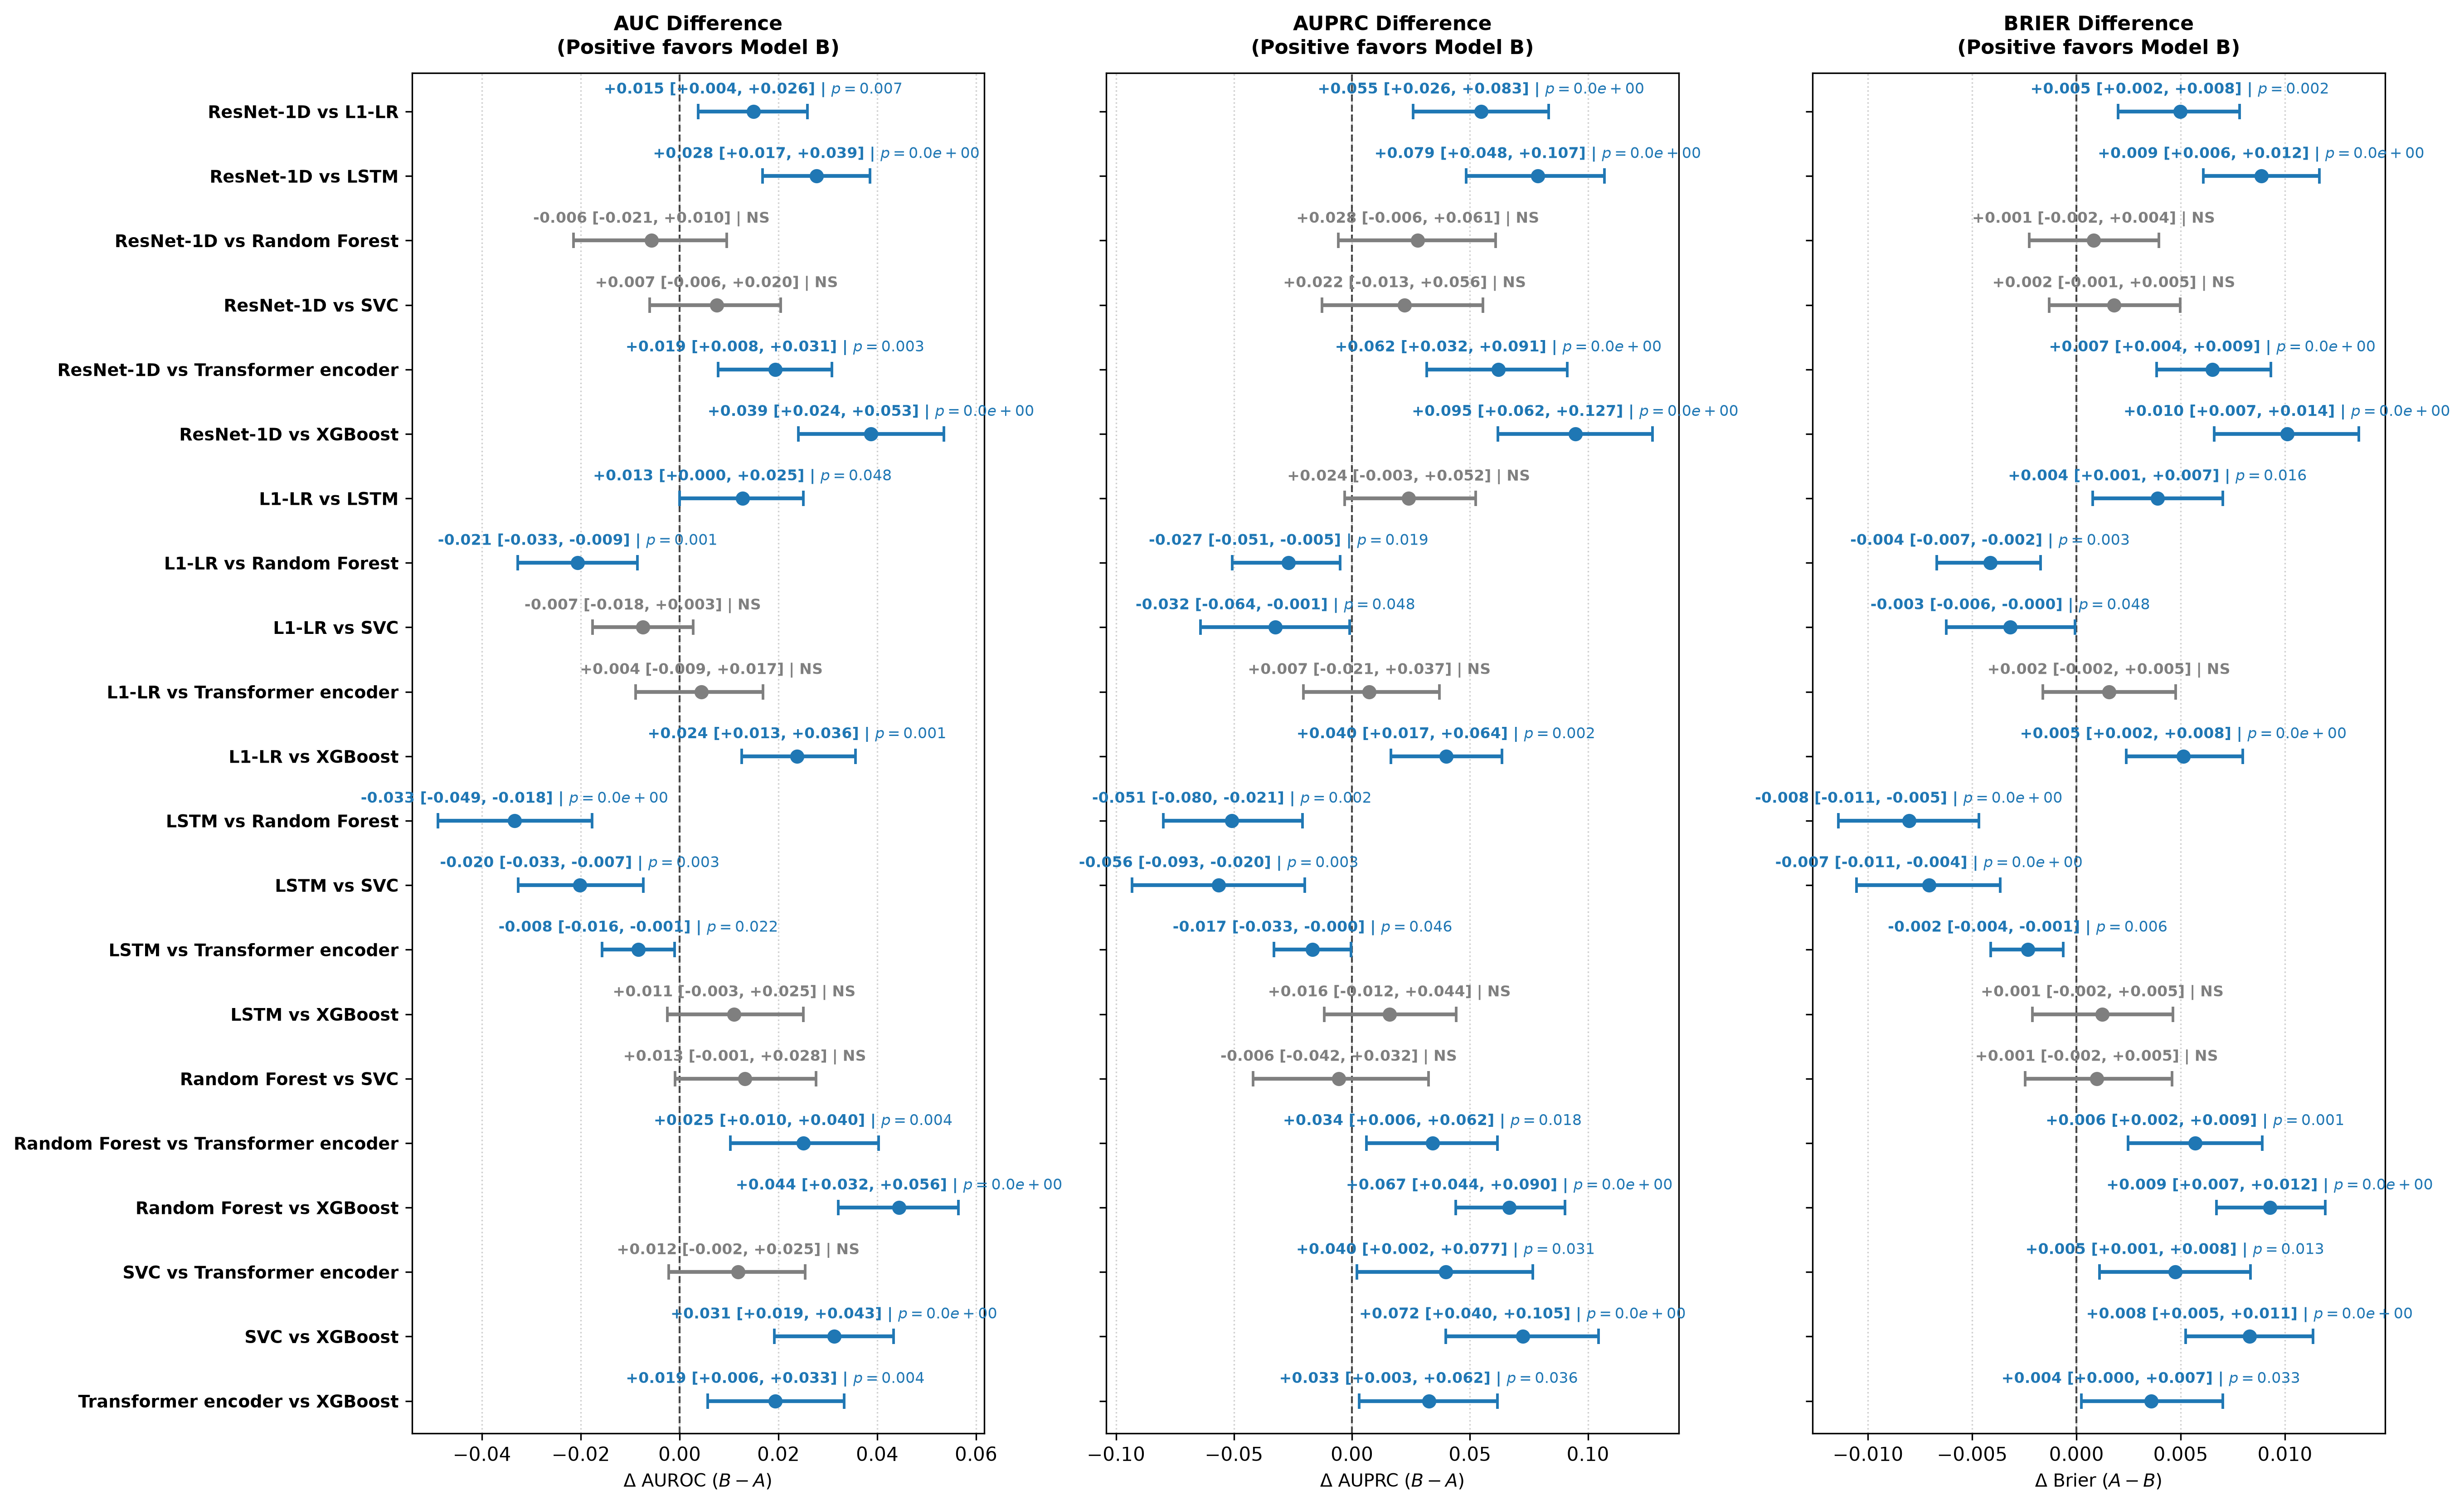

[Done] Processed 21 model comparison pairs.
[Saved] Figure: all_pairs_bootstrap_forest.pdf | Data: all_pairs_bootstrap_forest_data.csv

[Mode_Commonly_Used_Without_pmsi] 7 models loaded (excluding IGS2): ['InceptionTimeModified', 'Logistic_Regression_Lasso_TSFEL', 'LstmTimeModified', 'RandomForest_TSFEL', 'SVC_TSFEL', 'VanillaTransformerModified', 'XGBoost_TSFEL']


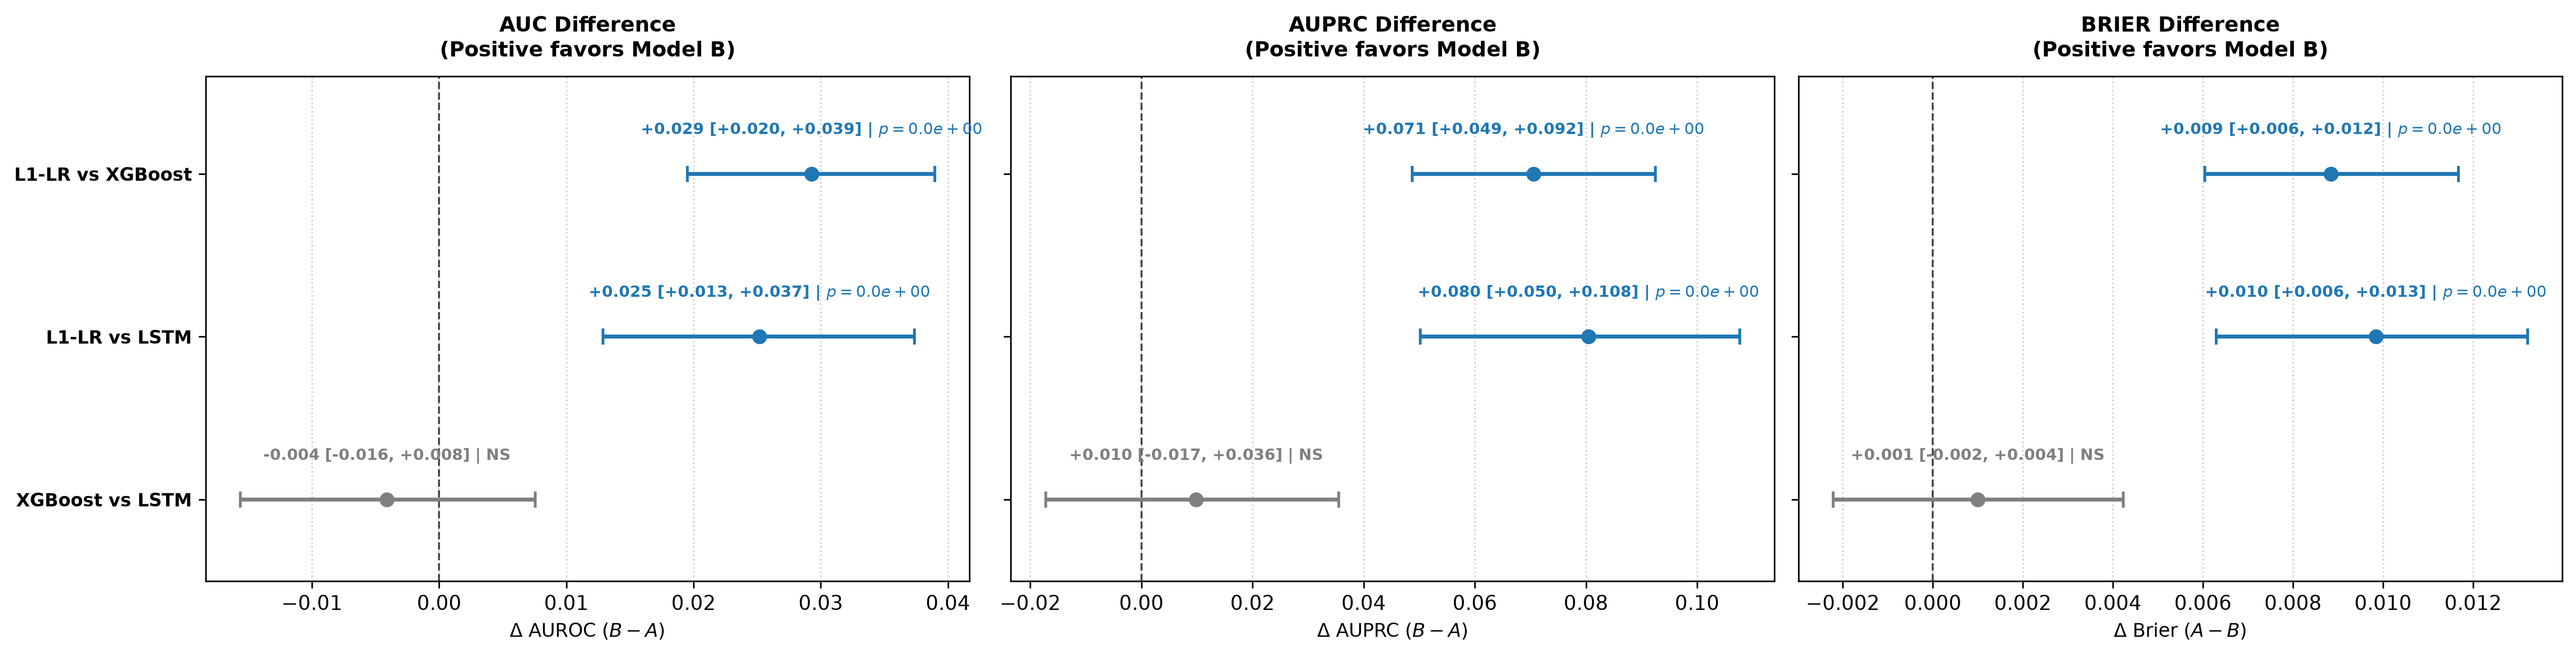

[Done] Processed 3 model comparison pairs.
[Saved] Figure: triplet_paired_bootstrap_auc_auprc_brier.pdf | Data: triplet_paired_bootstrap_auc_auprc_brier_data.csv


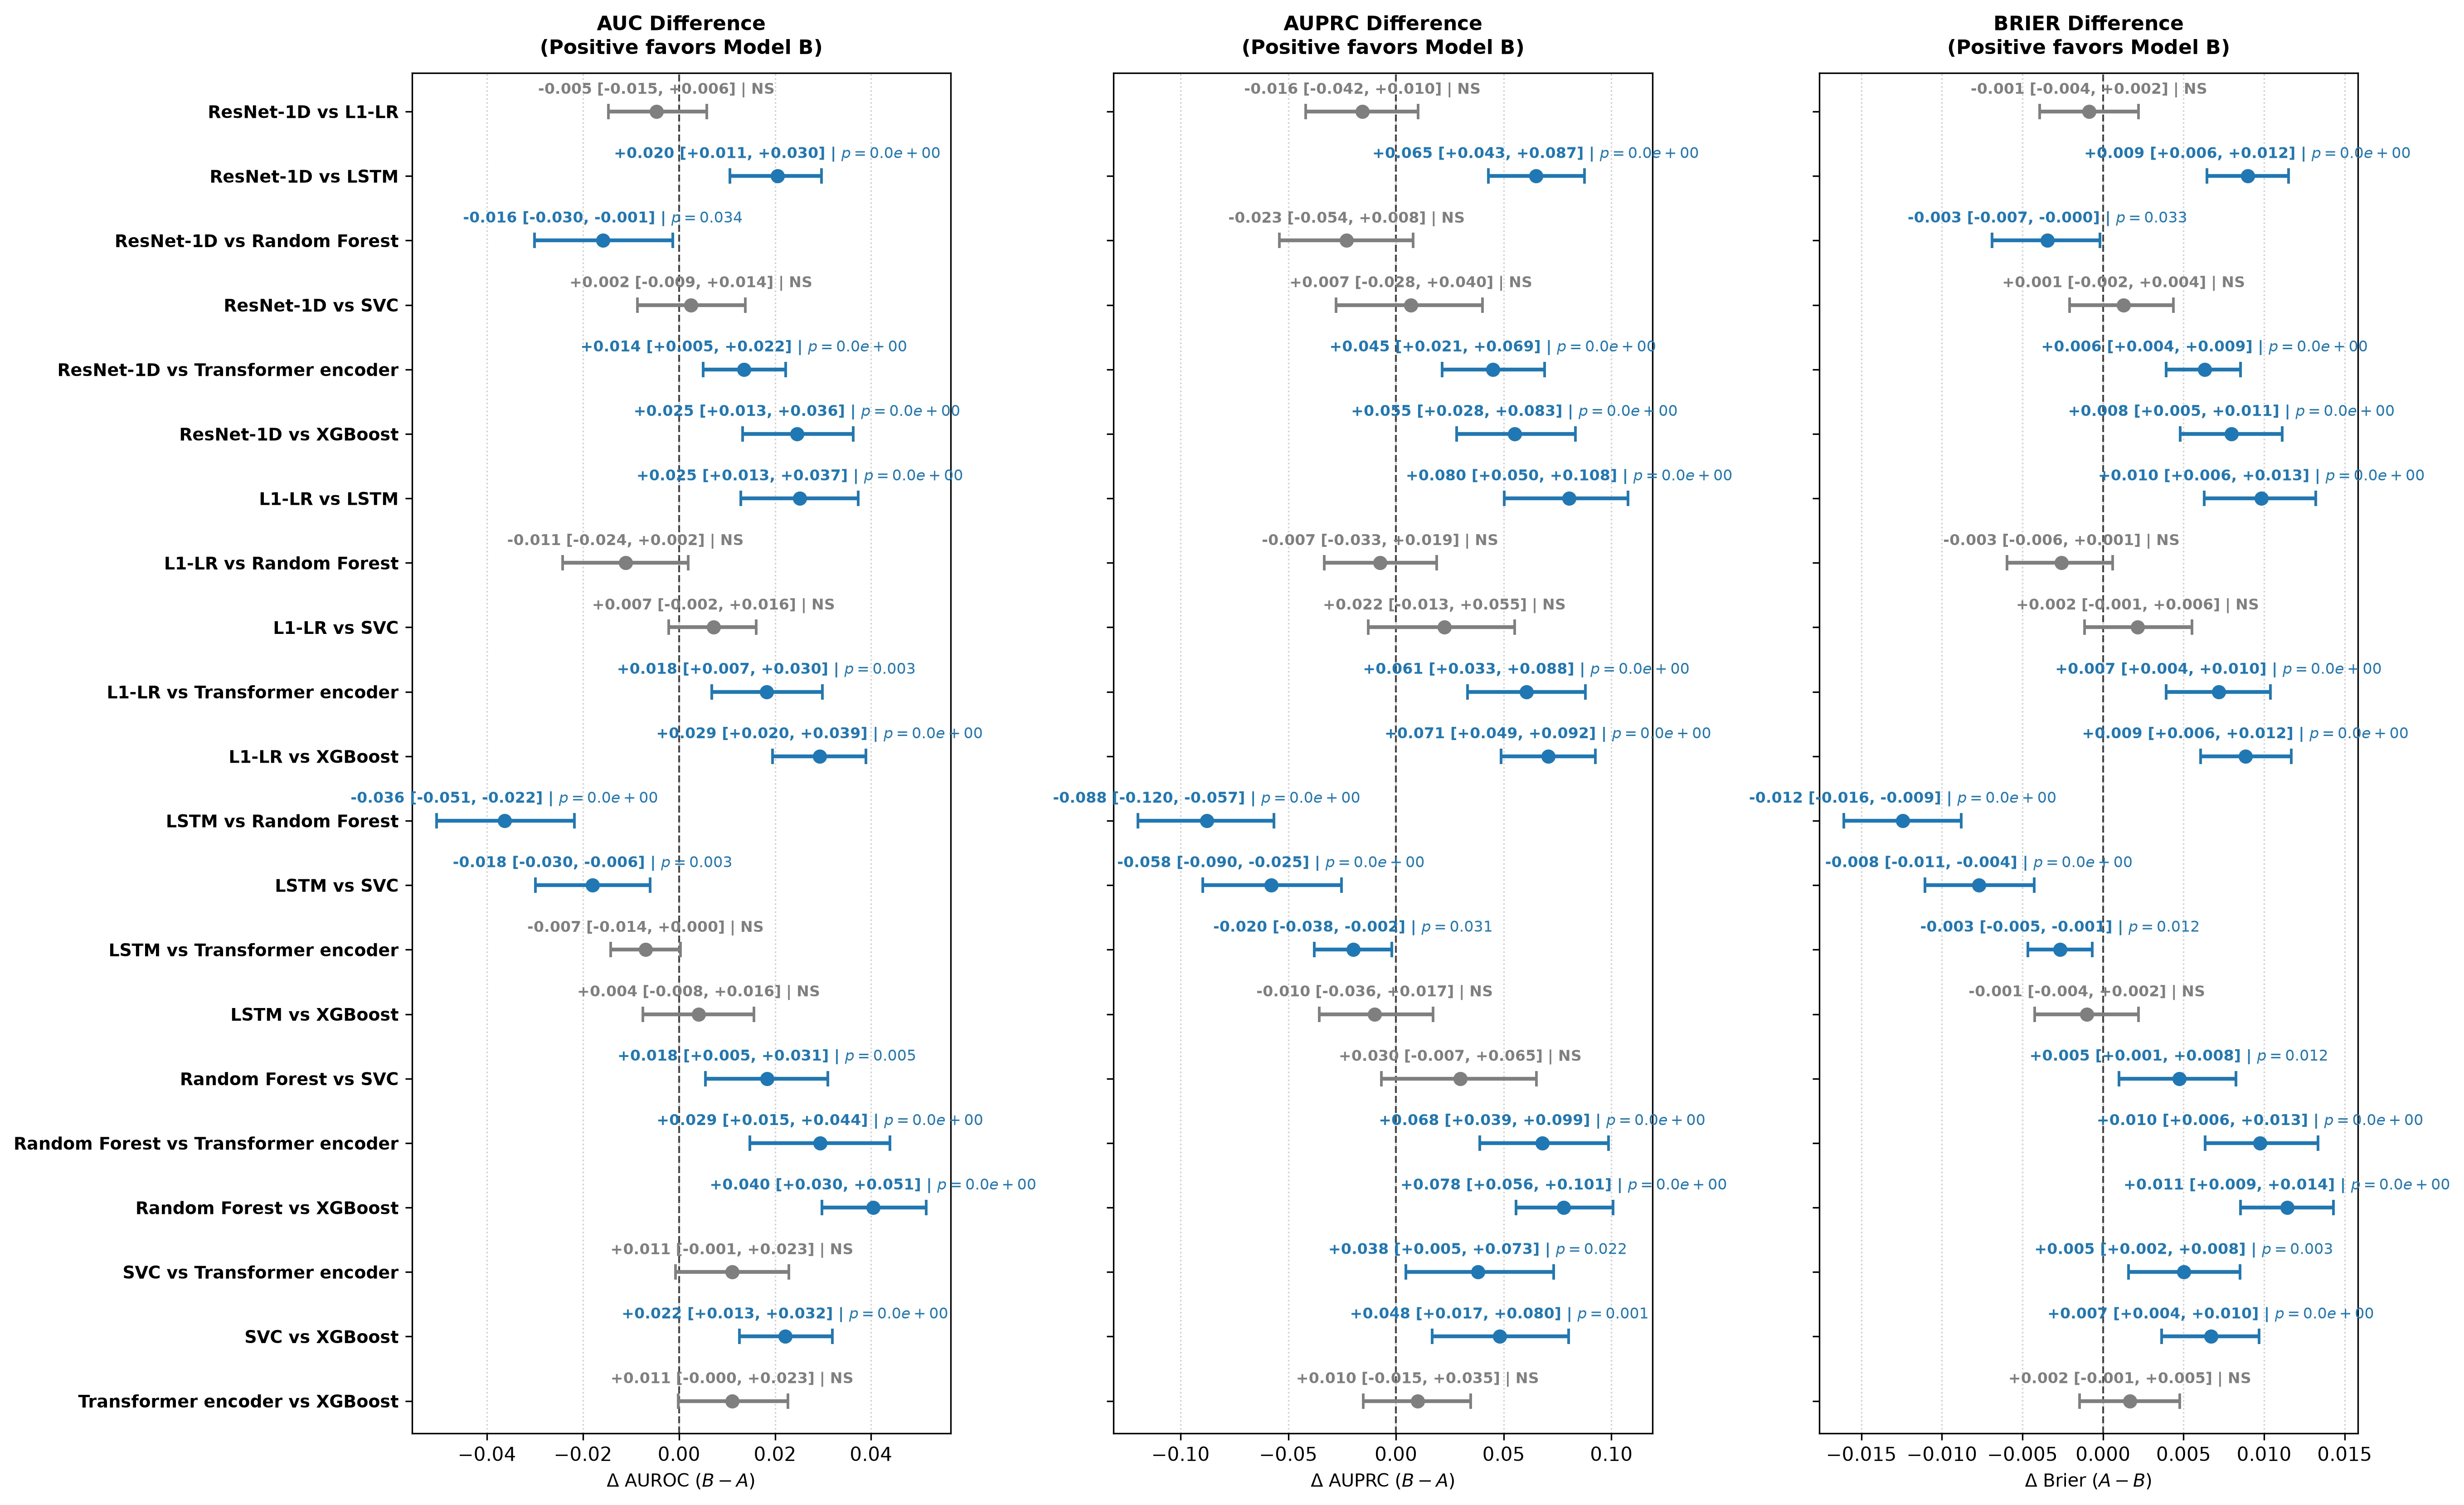

[Done] Processed 21 model comparison pairs.
[Saved] Figure: all_pairs_bootstrap_forest.pdf | Data: all_pairs_bootstrap_forest_data.csv

[Mode_Commonly_Used] 7 models loaded (excluding IGS2): ['InceptionTimeModified', 'Logistic_Regression_Lasso_TSFEL', 'LstmTimeModified', 'RandomForest_TSFEL', 'SVC_TSFEL', 'VanillaTransformerModified', 'XGBoost_TSFEL']


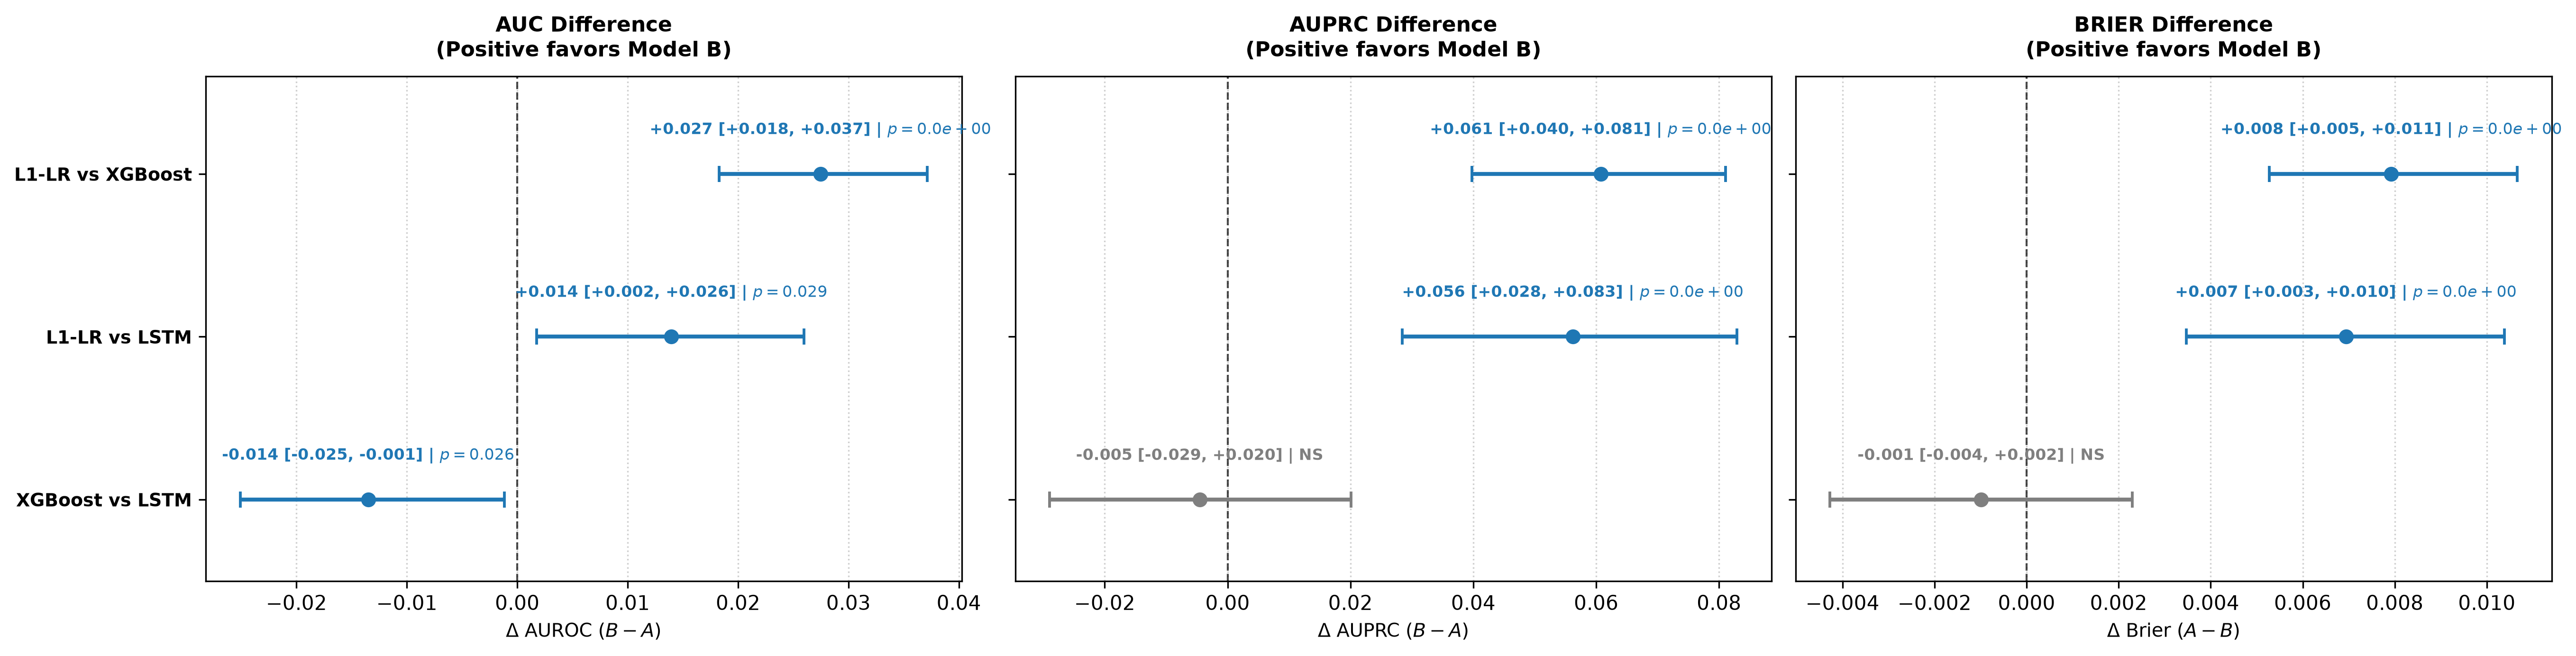

[Done] Processed 3 model comparison pairs.
[Saved] Figure: triplet_paired_bootstrap_auc_auprc_brier.pdf | Data: triplet_paired_bootstrap_auc_auprc_brier_data.csv


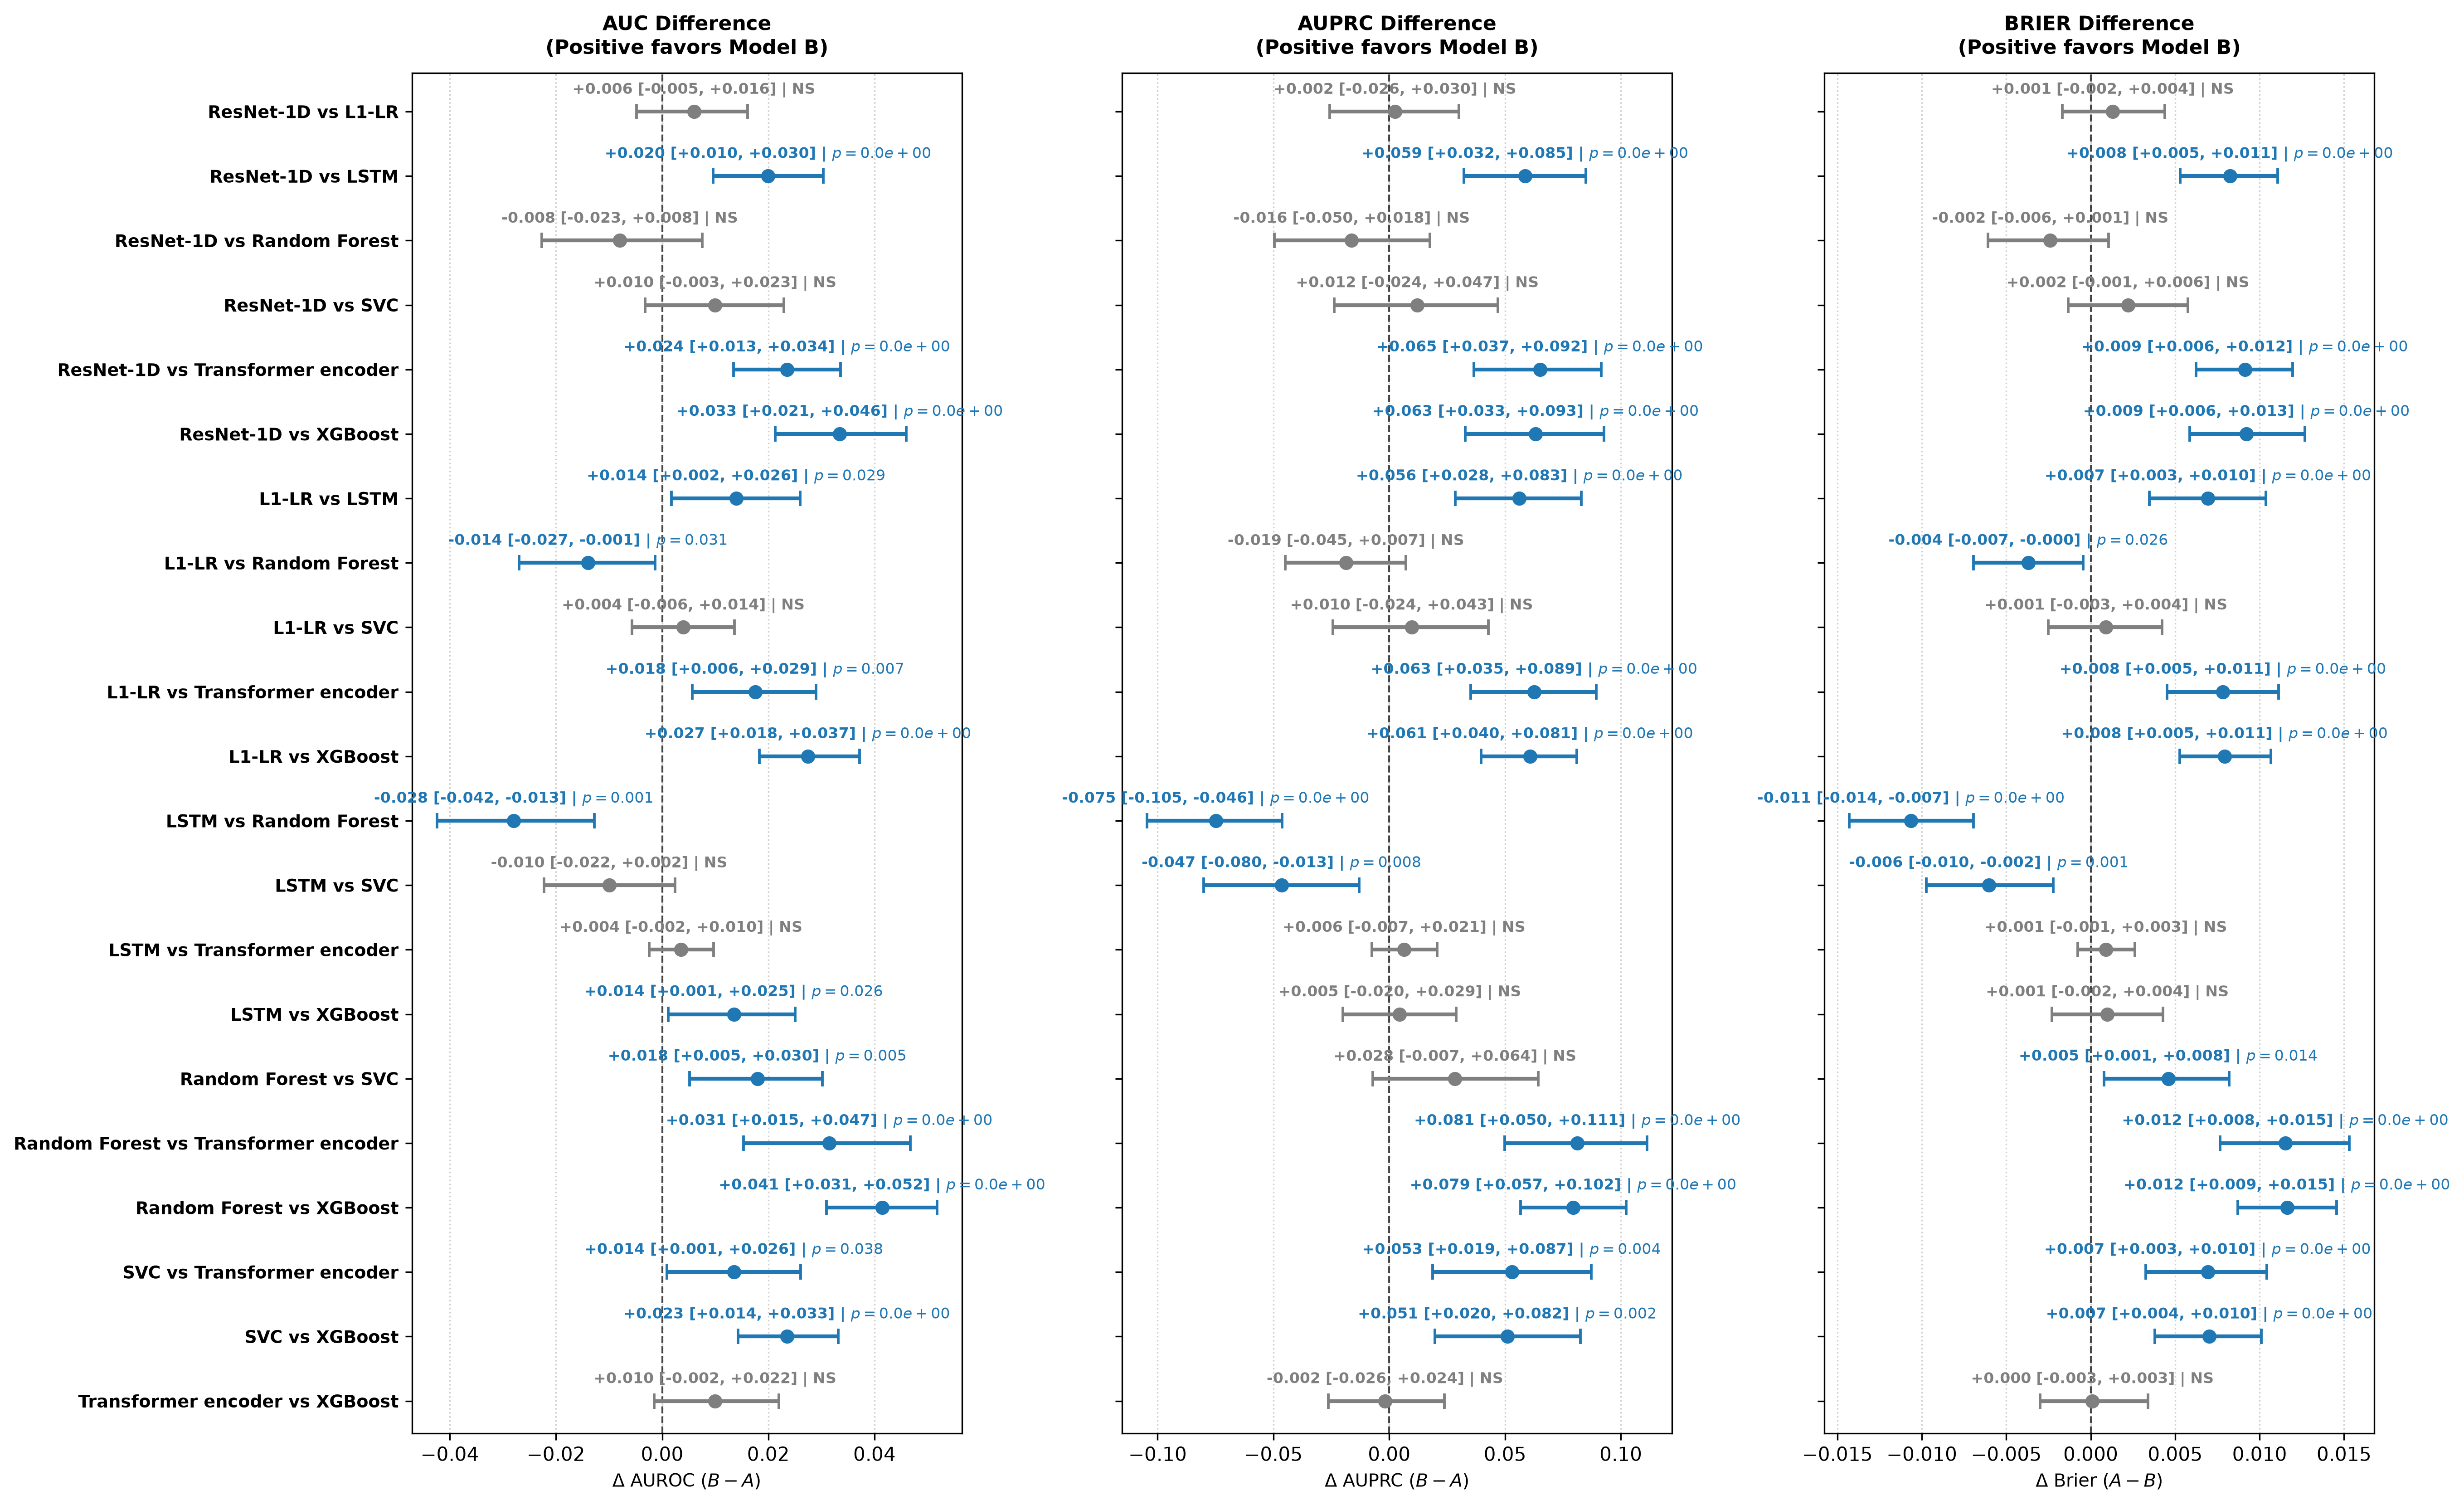

[Done] Processed 21 model comparison pairs.
[Saved] Figure: all_pairs_bootstrap_forest.pdf | Data: all_pairs_bootstrap_forest_data.csv


In [4]:
import itertools
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Union
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# =============================================================================
# 1. Path Configuration & Name Mapping
# =============================================================================
BASE_DIR = (
    PROJECT_ROOT
    / "outputs/no_duplicates_prio_first/isDeceased_lt_28d/target_col/24h_debut_rea_no-fill"
)

# Include Mode_IGS2 among the feature sets to evaluate
DATASETS = [
    "Mode_IGS2",
    "Mode_Commonly_Used_Without_pmsi",
    "Mode_Commonly_Used",
]

DEFAULT_NAMES_MAP = {
    "Logistic_Regression_Lasso_TSFEL": "L1-LR",
    "SVC_TSFEL": "SVC",
    "RandomForest_TSFEL": "Random Forest",
    "XGBoost_TSFEL": "XGBoost",
    "InceptionTimeModified": "ResNet-1D",
    "LstmTimeModified": "LSTM",
    "VanillaTransformerModified": "Transformer encoder",
    "Transformer Encoder": "Transformer encoder",
}

# =============================================================================
# 2. Analysis and Plotting Loop by Dataset / Mode
# =============================================================================
for d in DATASETS:
    dataset_dir = BASE_DIR / d
    output_dir = dataset_dir / "_comparative_analysis"
    output_dir.mkdir(parents=True, exist_ok=True)

    # Retrieve all joblib files while excluding the _comparative_analysis directory
    joblib_files = sorted(
        p
        for p in dataset_dir.rglob("all_res.joblib")
        if output_dir not in p.parents
    )

    # Load results while STRICTLY excluding the IGS2 baseline model (not the Mode_IGS2 directory)
    models_dict = {}
    for path in joblib_files:
        model_name = path.parent.parent.name
        
        # Filter out the standalone IGS2 score baseline
        if model_name.strip().lower() == "igs2":
            continue

        data = joblib.load(path)
        boot_data = data.get("bootstrap_holdout", {})
        if "distributions" in boot_data:
            models_dict[model_name] = boot_data["distributions"]

    if len(models_dict) < 2:
        print(f"[{d}] Fewer than 2 models found (excluding IGS2). Skipping...")
        continue

    print(f"\n[{d}] {len(models_dict)} models loaded (excluding IGS2): {list(models_dict.keys())}")

    # 1. Forest plot for the reference triplet (L1-LR vs XGBoost vs LSTM)
    comparison_figures.plot_paired_bootstrap_forest(
        models_dict=models_dict,
        output_dir=output_dir,
        selected_models=["Logistic_Regression_Lasso_TSFEL", "XGBoost_TSFEL", "LstmTimeModified"],
        names_map=DEFAULT_NAMES_MAP,
        save_filename="triplet_paired_bootstrap_auc_auprc_brier.pdf",
        show_plot=True,
    )

    # 2. Exhaustive forest plot for all possible pairwise comparisons
    comparison_figures.plot_paired_bootstrap_forest(
        models_dict=models_dict,
        output_dir=output_dir,
        selected_models=None,  # Evaluates all n-choose-2 combinations
        names_map=DEFAULT_NAMES_MAP,
        save_filename="all_pairs_bootstrap_forest.pdf",
        show_plot=True,
    )